In [1]:
import os
import pandas as pd
import numpy as np
import re # Import regular expressions for extracting numbers

path_to_scenarios = '/home/abhis/india_power/scenarios'
# Define scenario names explicitly or detect automatically
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list
# scenario_names = ['iced_mid_ra_2040_1','iced_mid_ra_2040_2','iced_mid_ra_2040_3'] # Example: Explicit list

scenario_names = ['capex_pier_prm_108_cc_90_hardovergen_2040_1','capex_pier_prm_108_cc_90_hardovergen_2040_2','capex_pier_prm_108_cc_90_hardovergen_2040_3',
                'capex_pier_prm_108_cc_90_hardovergen_2040_4','capex_pier_prm_108_cc_90_hardovergen_2040_5','capex_pier_prm_108_cc_90_hardovergen_2040_6',
                'capex_pier_prm_108_cc_90_hardovergen_2040_7','capex_pier_prm_108_cc_90_hardovergen_2040_8','capex_pier_prm_108_cc_90_hardovergen_2040_9',
                'capex_pier_prm_108_cc_90_hardovergen_2040_10','capex_pier_prm_108_cc_90_hardovergen_2040_11','capex_pier_prm_108_cc_90_hardovergen_2040_12',
                'capex_pier_prm_108_cc_90_hardovergen_2040_13','capex_pier_prm_108_cc_90_hardovergen_2040_14','capex_pier_prm_108_cc_90_hardovergen_2040_15',
                'capex_pier_prm_108_cc_90_hardovergen_2040_16','capex_pier_prm_108_cc_90_hardovergen_2040_17','capex_pier_prm_108_cc_90_hardovergen_2040_18'] # Example: Explicit list


print(f"Processing scenarios for system_load_zone_timepoint: {scenario_names}")

all_system_load_data = []

for scenario_name in scenario_names:
    scenario_path = os.path.join(path_to_scenarios, scenario_name)
    if not os.path.isdir(scenario_path):
        print(f"Warning: Scenario directory not found: {scenario_path}")
        continue

    # Iterate through weather iterations
    for weather_folder in os.listdir(scenario_path):
        if weather_folder.startswith('weather_iteration_'):
            weather_match = re.search(r'\d+', weather_folder)
            if not weather_match:
                continue
            weather_iteration = int(weather_match.group())
            weather_path = os.path.join(scenario_path, weather_folder)
            if not os.path.isdir(weather_path):
                continue

            # Iterate through hydro iterations
            for hydro_folder in os.listdir(weather_path):
                if hydro_folder.startswith('hydro_iteration_'):
                    hydro_match = re.search(r'\d+', hydro_folder)
                    if not hydro_match:
                        continue
                    hydro_iteration = int(hydro_match.group())
                    hydro_path = os.path.join(weather_path, hydro_folder)
                    if not os.path.isdir(hydro_path):
                        continue

                    # Iterate through availability iterations
                    for avail_folder in os.listdir(hydro_path):
                        if avail_folder.startswith('availability_iteration_'):
                            avail_match = re.search(r'\d+', avail_folder)
                            if not avail_match:
                                continue
                            availability_iteration = int(avail_match.group())
                            avail_path = os.path.join(hydro_path, avail_folder)
                            if not os.path.isdir(avail_path):
                                continue

                            # Construct path to system_load_zone_timepoint.csv in results folder
                            system_load_path = os.path.join(avail_path, 'results', 'system_load_zone_timepoint.csv')

                            if os.path.exists(system_load_path):
                                try:
                                    # Read the system_load_zone_timepoint.csv file
                                    df_sys_load = pd.read_csv(system_load_path)

                                    # Add iteration columns
                                    df_sys_load['scenario_name'] = scenario_name
                                    df_sys_load['weather_iteration'] = weather_iteration
                                    df_sys_load['hydro_iteration'] = hydro_iteration
                                    df_sys_load['availability_iteration'] = availability_iteration

                                    # Optional: Reorder columns (e.g., put iterations first)
                                    iteration_cols = ['scenario_name', 'weather_iteration', 'hydro_iteration', 'availability_iteration']
                                    original_cols = [col for col in df_sys_load.columns if col not in iteration_cols]
                                    df_sys_load = df_sys_load[iteration_cols + original_cols]

                                    all_system_load_data.append(df_sys_load)
                                except Exception as e:
                                    print(f"Error reading {system_load_path}: {e}")
                            else:
                                print(f"Warning: system_load_zone_timepoint.csv not found in {os.path.join(avail_path, 'results')}")

# Concatenate all dataframes
if all_system_load_data:
    final_system_load_df = pd.concat(all_system_load_data, ignore_index=True)
    print("Combined system_load_zone_timepoint DataFrame created successfully.")
    # Display the first few rows (optional)
    # print(final_system_load_df.head())
else:
    print("No system_load_zone_timepoint.csv files were found or processed.")

# Calculate and overwrite static_load_mw based on the load balance equation

if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    # Ensure required columns exist and are numeric, coercing errors to NaN
    cols_to_check = ['total_power_mw', 'net_imports_mw', 'unserved_energy_mw', 'overgeneration_mw']
    all_cols_present = True
    for col in cols_to_check:
        if col in final_system_load_df.columns:
            final_system_load_df[col] = pd.to_numeric(final_system_load_df[col], errors='coerce')
        else:
            print(f"Error: Required column '{col}' not found in DataFrame. Cannot calculate static load.")
            all_cols_present = False
            break # Stop if a required column is missing

    # Perform the calculation only if all required columns are present
    if all_cols_present:
        # Check if 'static_load_mw' column exists before trying to overwrite
        if 'static_load_mw' not in final_system_load_df.columns:
             print("Warning: 'static_load_mw' column not found. Creating it with calculated values.")

        # Calculate and overwrite the 'static_load_mw' column
        # Fill potential NaN values created by pd.to_numeric with 0 before calculation
        final_system_load_df['static_load_mw'] = (
            final_system_load_df['total_power_mw'].fillna(0) +
            final_system_load_df['net_imports_mw'].fillna(0) +
            final_system_load_df['unserved_energy_mw'].fillna(0) -
            final_system_load_df['overgeneration_mw'].fillna(0)
        )
        print("Column 'static_load_mw' calculated and updated/created.")

        # Display head with the updated column and its components
        print("\nDataFrame head with calculated static load:")
        display_cols = ['static_load_mw'] + cols_to_check
        print(final_system_load_df[display_cols].head())
else:
    print("final_system_load_df not found or is empty. Run the previous cell first.")

# Calculate and overwrite static_load_mw based on the load balance equation

if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    # Ensure required columns exist and are numeric, coercing errors to NaN
    cols_to_check = ['total_power_mw', 'net_imports_mw', 'unserved_energy_mw', 'overgeneration_mw']
    all_cols_present = True
    for col in cols_to_check:
        if col in final_system_load_df.columns:
            final_system_load_df[col] = pd.to_numeric(final_system_load_df[col], errors='coerce')
        else:
            print(f"Error: Required column '{col}' not found in DataFrame. Cannot calculate static load.")
            all_cols_present = False
            break # Stop if a required column is missing

    # Perform the calculation only if all required columns are present
    if all_cols_present:
        # Check if 'static_load_mw' column exists before trying to overwrite
        if 'static_load_mw' not in final_system_load_df.columns:
             print("Warning: 'static_load_mw' column not found. Creating it with calculated values.")

        # Calculate and overwrite the 'static_load_mw' column
        # Fill potential NaN values created by pd.to_numeric with 0 before calculation
        final_system_load_df['static_load_mw'] = (
            final_system_load_df['total_power_mw'].fillna(0) +
            final_system_load_df['net_imports_mw'].fillna(0) +
            final_system_load_df['unserved_energy_mw'].fillna(0) -
            final_system_load_df['overgeneration_mw'].fillna(0)
        )
        print("Column 'static_load_mw' calculated and updated/created.")

        # Display head with the updated column and its components
        # print("\nDataFrame head with calculated static load:")
        # display_cols = ['static_load_mw'] + cols_to_check
        # print(final_system_load_df[display_cols].head())

    # --- Add timestamp column ---
    try:
        # Ensure timepoint is string
        final_system_load_df['timepoint_str'] = final_system_load_df['timepoint'].astype(str)
        # Extract date and hour parts
        final_system_load_df['date_str'] = final_system_load_df['timepoint_str'].str[:8]
        final_system_load_df['hour_str'] = final_system_load_df['timepoint_str'].str[8:]
        # Convert hour (assuming HE 01-24) to 0-23 index
        final_system_load_df['hour_int'] = final_system_load_df['hour_str'].astype(int) - 1
        # Create timestamp objects
        final_system_load_df['timestamp'] = pd.to_datetime(final_system_load_df['date_str'], format='%Y%m%d') + pd.to_timedelta(final_system_load_df['hour_int'], unit='h')
        # Drop temporary columns
        final_system_load_df = final_system_load_df.drop(columns=['timepoint_str', 'date_str', 'hour_str', 'hour_int'])
        print("Timestamp column added successfully.")

        # --- Reorder columns to put timestamp first ---
        cols = list(final_system_load_df.columns)
        # Remove timestamp from list and insert at the beginning
        cols.insert(0, cols.pop(cols.index('timestamp')))
        final_system_load_df = final_system_load_df[cols]
        print("Columns reordered with timestamp first.")
        # ---------------------------------------------
    except Exception as e:
        print(f"Error creating or reordering timestamp column: {e}")
    # ----------------------------

    # --- Remove scenario_name column if it exists ---
    if 'scenario_name' in final_system_load_df.columns:
        final_system_load_df = final_system_load_df.drop(columns=['scenario_name'])
        print("Column 'scenario_name' removed.")
    else:
        print("Column 'scenario_name' not found, skipping removal.")
    # ---------------------------------------------

    # Display head with final structure (optional)
    print("\nFinal DataFrame head:")
    print(final_system_load_df.head())
else:
    print("final_system_load_df not found or is empty. Skipping timestamp creation and column removal.")



Processing scenarios for system_load_zone_timepoint: ['capex_pier_prm_108_cc_90_hardovergen_2040_1', 'capex_pier_prm_108_cc_90_hardovergen_2040_2', 'capex_pier_prm_108_cc_90_hardovergen_2040_3', 'capex_pier_prm_108_cc_90_hardovergen_2040_4', 'capex_pier_prm_108_cc_90_hardovergen_2040_5', 'capex_pier_prm_108_cc_90_hardovergen_2040_6', 'capex_pier_prm_108_cc_90_hardovergen_2040_7', 'capex_pier_prm_108_cc_90_hardovergen_2040_8', 'capex_pier_prm_108_cc_90_hardovergen_2040_9', 'capex_pier_prm_108_cc_90_hardovergen_2040_10', 'capex_pier_prm_108_cc_90_hardovergen_2040_11', 'capex_pier_prm_108_cc_90_hardovergen_2040_12', 'capex_pier_prm_108_cc_90_hardovergen_2040_13', 'capex_pier_prm_108_cc_90_hardovergen_2040_14', 'capex_pier_prm_108_cc_90_hardovergen_2040_15', 'capex_pier_prm_108_cc_90_hardovergen_2040_16', 'capex_pier_prm_108_cc_90_hardovergen_2040_17', 'capex_pier_prm_108_cc_90_hardovergen_2040_18']
Combined system_load_zone_timepoint DataFrame created successfully.
Column 'static_load_mw'

In [2]:

# Define the load zone to aggregate. Use 'national' for all zones.
selected_load_zone = 'national' # Options: 'national' or a specific load_zone name (e.g., 'Goa')

# Check if final_system_load_df exists and is not empty
if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    if selected_load_zone.lower() == 'national':
        print(f"Aggregating system load for: National")
        # --- Aggregate for National ---
        # Define the columns to group by (timestamp, iterations, original timepoint)
        grouping_cols = ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration', 'timepoint']
        # Define columns to sum
        summing_cols = ['static_load_mw', 'total_power_mw', 'net_imports_mw', 'overgeneration_mw', 'unserved_energy_mw']
        # Ensure grouping cols exist
        valid_grouping_cols = [col for col in grouping_cols if col in final_system_load_df.columns]
        if len(valid_grouping_cols) != len(grouping_cols):
            print(f"Warning: Missing grouping columns. Using: {valid_grouping_cols}")

        # Group by the defined columns and sum the relevant columns across original load zones
        aggregated_system_load_df = final_system_load_df.groupby(valid_grouping_cols, as_index=False)[summing_cols].sum()

        # Add the 'load_zone' column with 'national' value
        aggregated_system_load_df['load_zone'] = 'national'

        # Reorder columns: timestamp first, then iterations, timepoint, load_zone, summed columns
        final_cols_order = valid_grouping_cols + ['load_zone'] + summing_cols
        # Ensure all columns exist before reordering
        final_cols_order = [col for col in final_cols_order if col in aggregated_system_load_df.columns]
        aggregated_system_load_df = aggregated_system_load_df[final_cols_order]
        print("National aggregated system load DataFrame created successfully.")
        # -----------------------------
    else:
        print(f"Filtering system load for: {selected_load_zone}")
        # --- Filter for a specific load zone ---
        if 'load_zone' in final_system_load_df.columns:
            aggregated_system_load_df = final_system_load_df[final_system_load_df['load_zone'] == selected_load_zone].copy()
            if aggregated_system_load_df.empty:
                print(f"Warning: No data found for load zone '{selected_load_zone}'. Check spelling and data.")
            else:
                print(f"Filtered DataFrame for load zone '{selected_load_zone}' created successfully.")
                # Column order should already be correct from previous cell
        else:
            print("Error: 'load_zone' column not found in final_system_load_df. Cannot filter by specific zone.")
            aggregated_system_load_df = pd.DataFrame() # Create empty df to avoid errors later
        # ------------------------------------

    # Display the first few rows (optional)
    if not aggregated_system_load_df.empty:
        print("\nAggregated/Filtered DataFrame head:")
        print(aggregated_system_load_df.head())
else:
    print("final_system_load_df not found or is empty. Run the previous cell first.")
    aggregated_system_load_df = pd.DataFrame() # Ensure variable exists even if previous cell failed

Aggregating system load for: National


National aggregated system load DataFrame created successfully.

Aggregated/Filtered DataFrame head:
   timestamp  weather_iteration  hydro_iteration  availability_iteration  \
0 2040-04-01                  1                1                       1   
1 2040-04-01                  2                2                       2   
2 2040-04-01                  3                3                       3   
3 2040-04-01                  4                4                       4   
4 2040-04-01                  5                5                       5   

    timepoint load_zone  static_load_mw  total_power_mw  net_imports_mw  \
0  2040040101  national   356639.894731   360266.026778    -3626.132047   
1  2040040101  national   344471.731626   348557.925327    -4086.193701   
2  2040040101  national   333142.308974   336711.603864    -3569.294890   
3  2040040101  national   346976.546262   352467.652978    -5491.106715   
4  2040040101  national   347954.250561   351197.666994    -3243.41

Debug: Type of aggregated_system_load_df: <class 'pandas.core.frame.DataFrame'>
Debug: Is aggregated_system_load_df empty? False
Debug: Shape of aggregated_system_load_df: (113880, 11)
Debug: First 5 rows of aggregated_system_load_df:
   timestamp  weather_iteration  hydro_iteration  availability_iteration  \
0 2040-04-01                  1                1                       1   
1 2040-04-01                  2                2                       2   
2 2040-04-01                  3                3                       3   
3 2040-04-01                  4                4                       4   
4 2040-04-01                  5                5                       5   

    timepoint load_zone  static_load_mw  total_power_mw  net_imports_mw  \
0  2040040101  national   356639.894731   360266.026778    -3626.132047   
1  2040040101  national   344471.731626   348557.925327    -4086.193701   
2  2040040101  national   333142.308974   336711.603864    -3569.294890   
3  20400

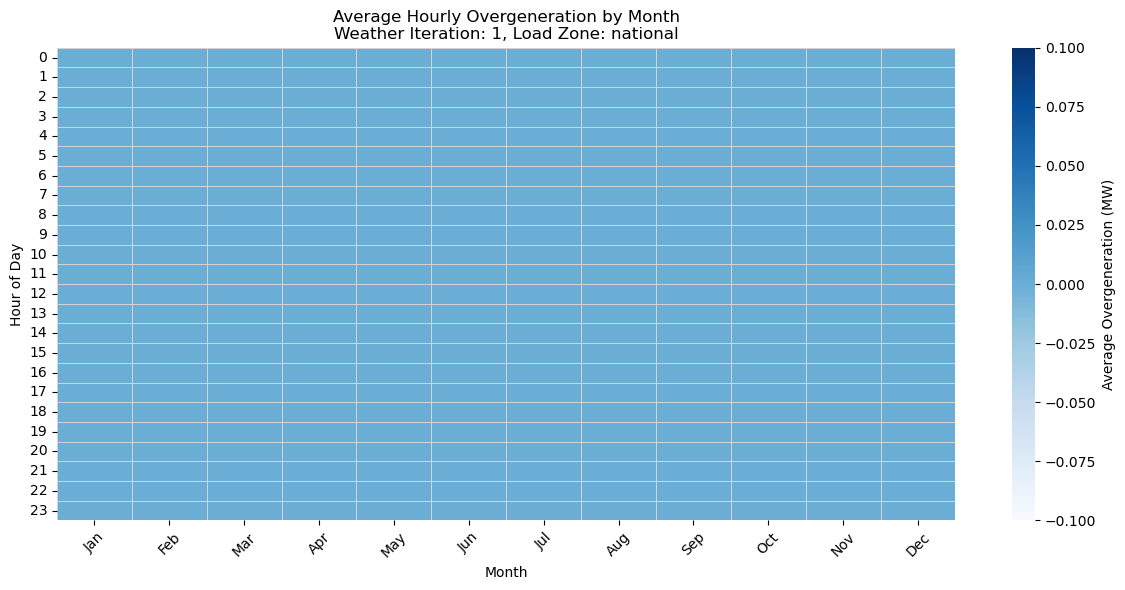

Could not generate Unserved Energy heatmap for iteration 1: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 2


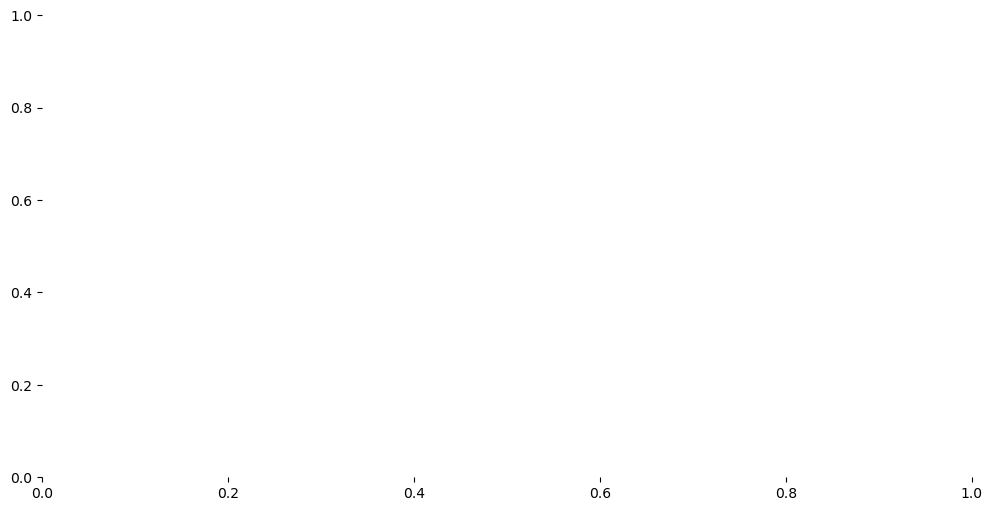

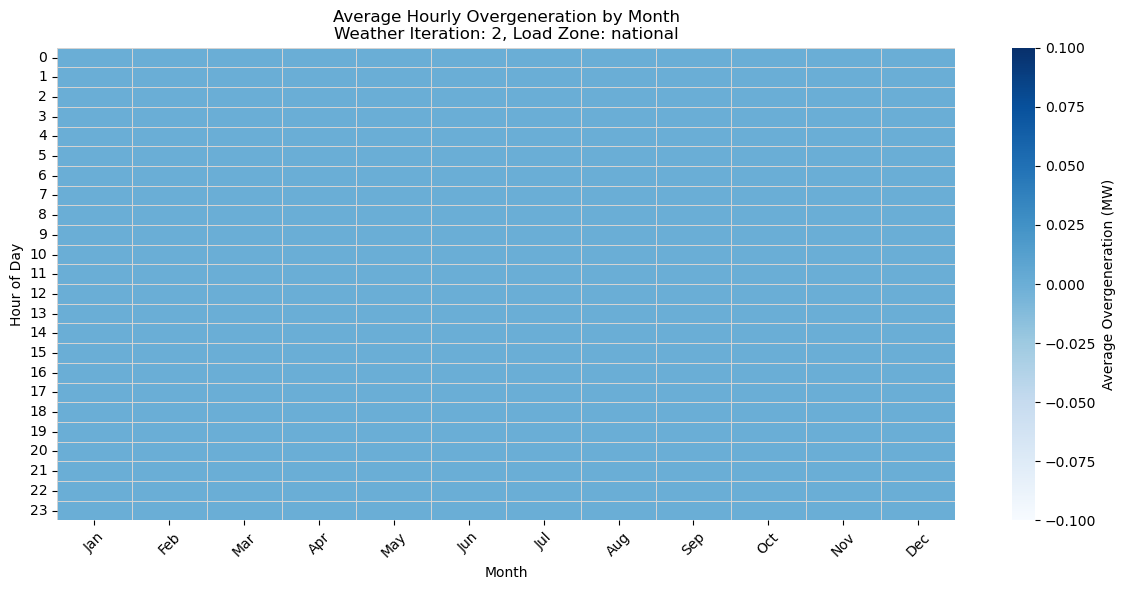

Could not generate Unserved Energy heatmap for iteration 2: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 3


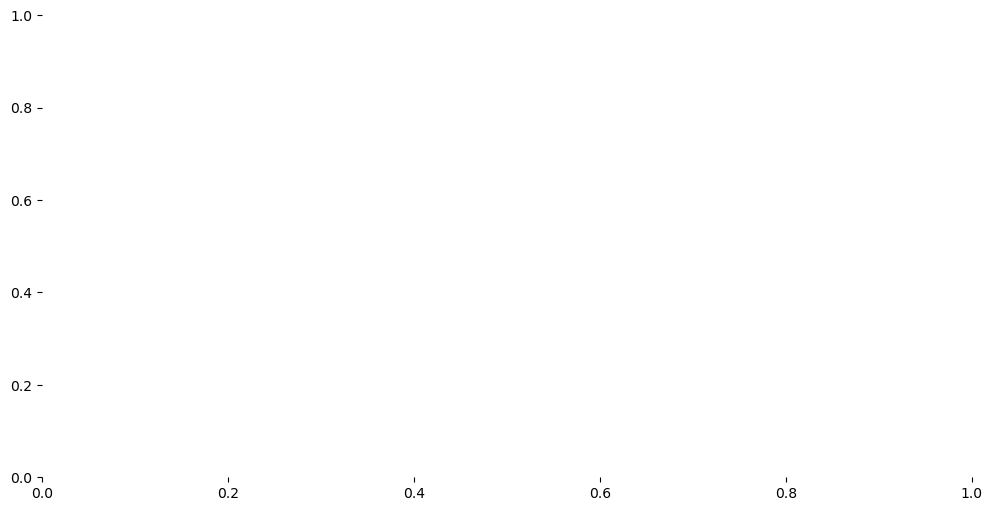

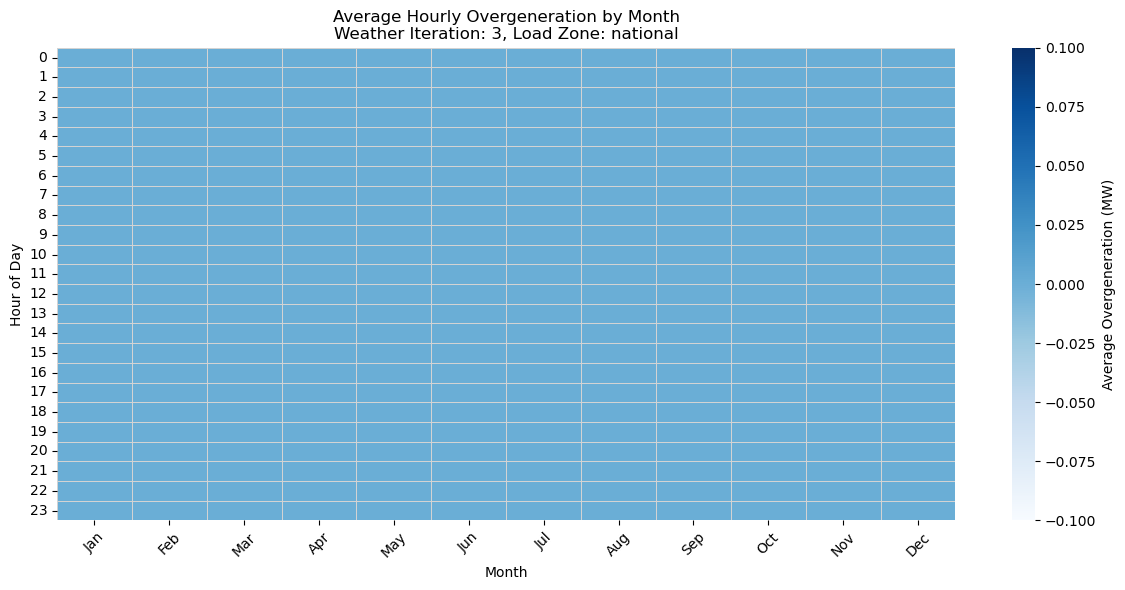

Could not generate Unserved Energy heatmap for iteration 3: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 4


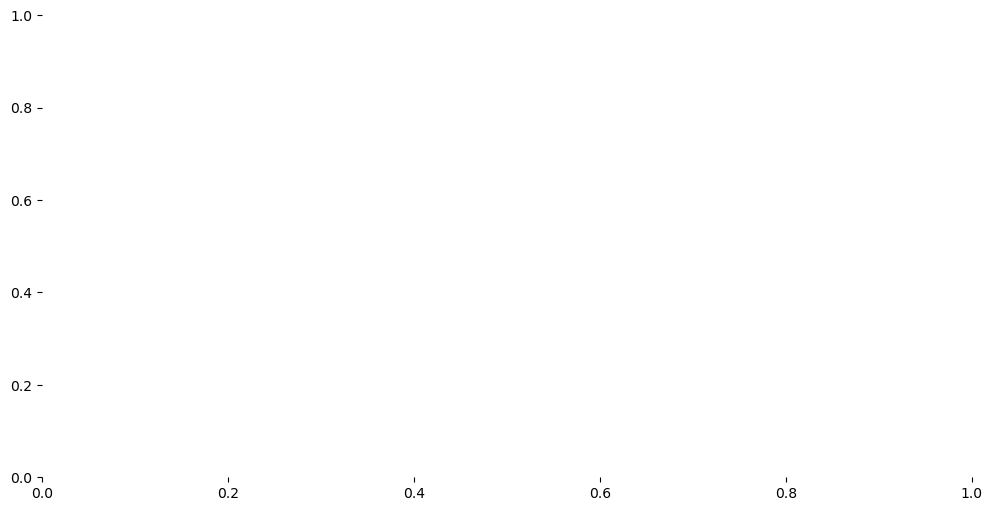

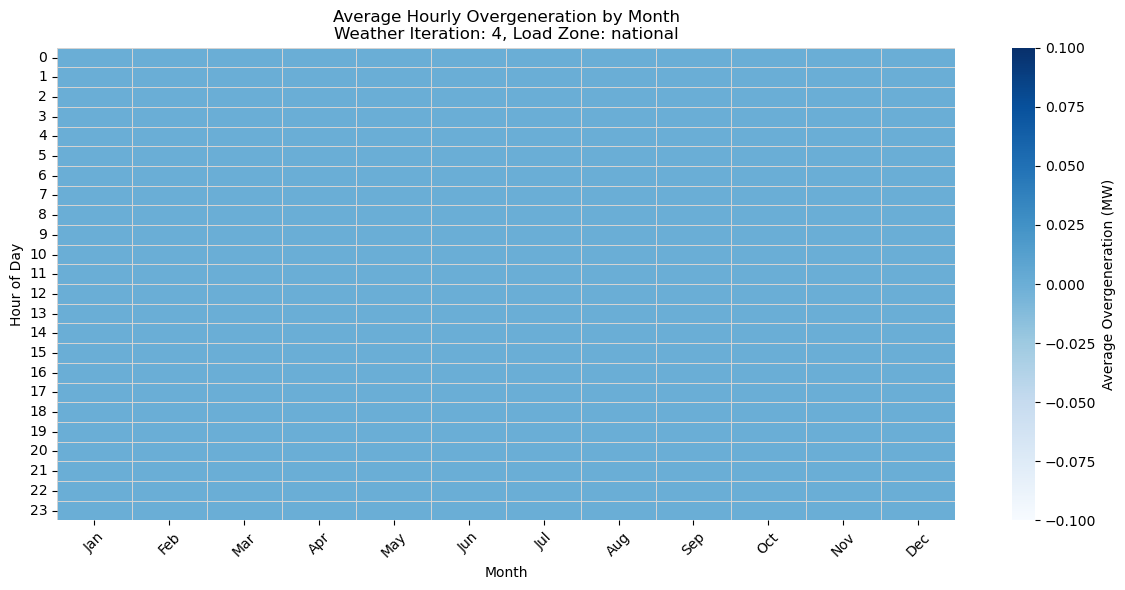

Could not generate Unserved Energy heatmap for iteration 4: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 5


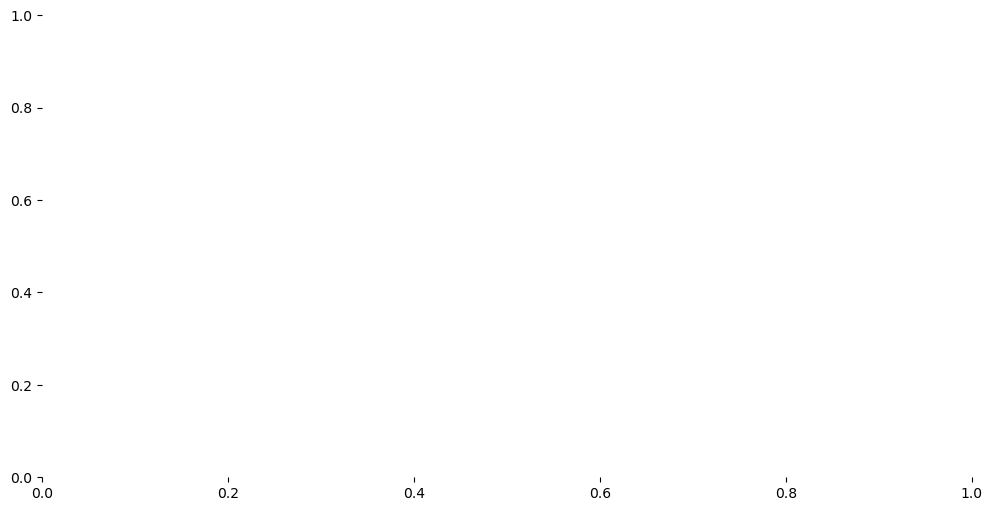

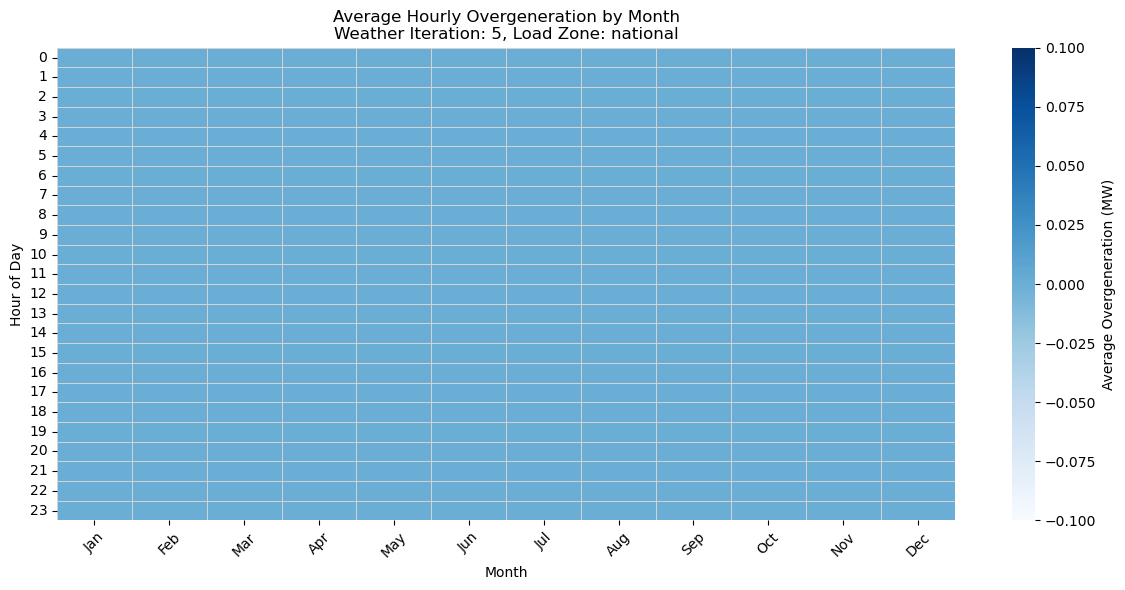

Could not generate Unserved Energy heatmap for iteration 5: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 6


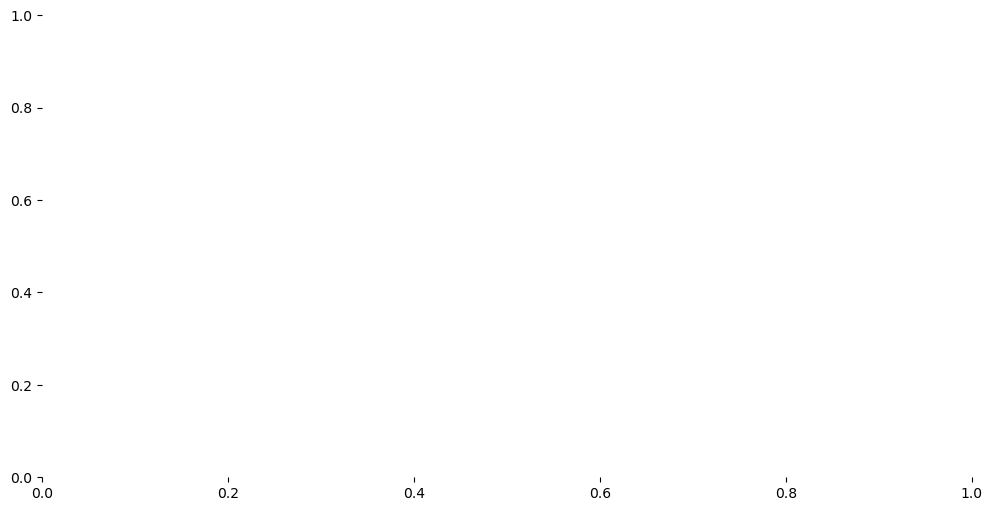

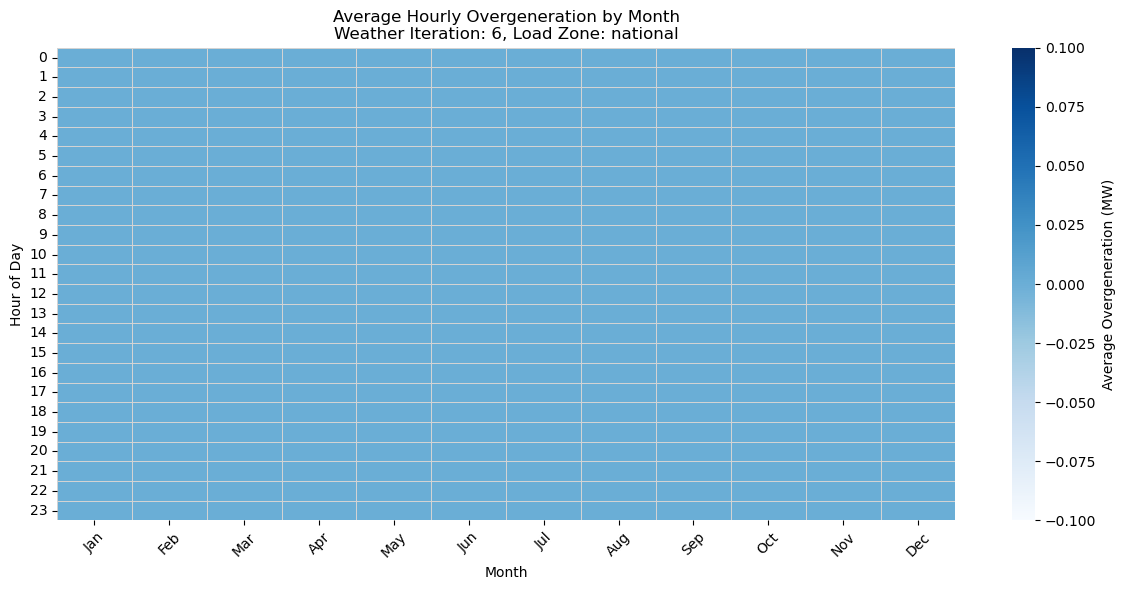

Could not generate Unserved Energy heatmap for iteration 6: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 7


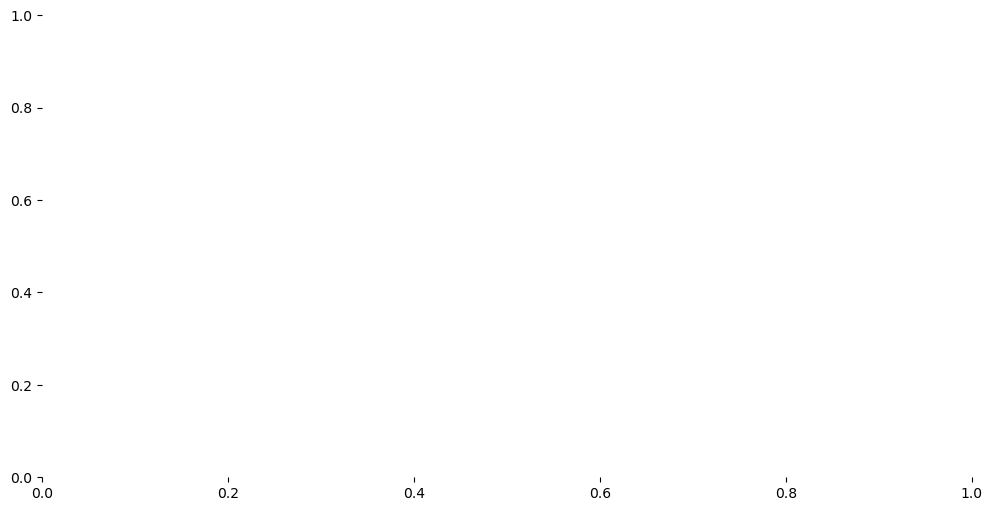

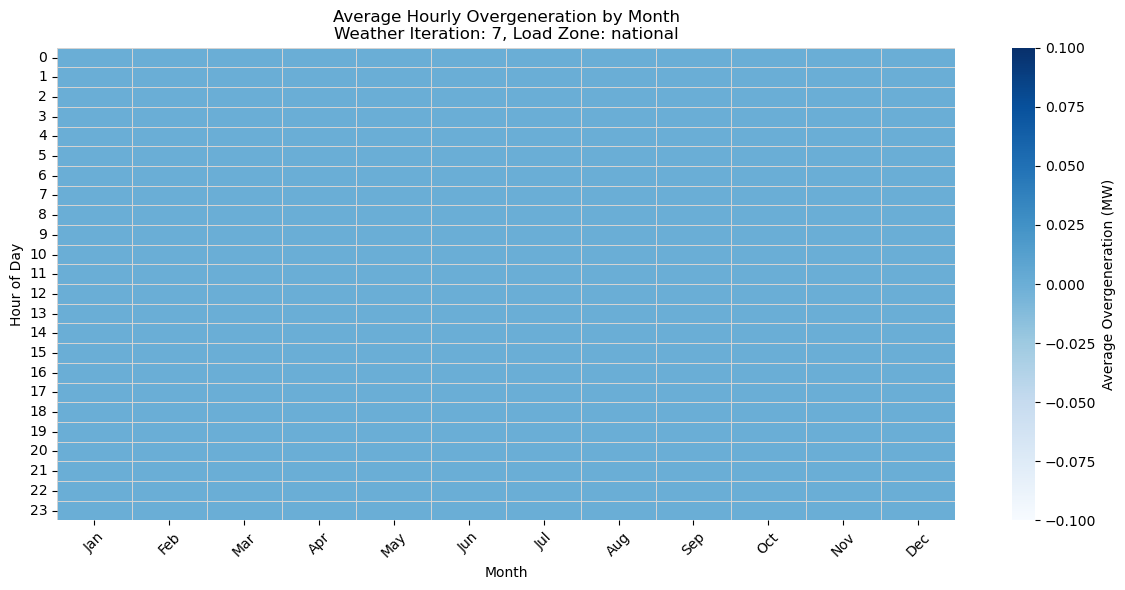

Could not generate Unserved Energy heatmap for iteration 7: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 8


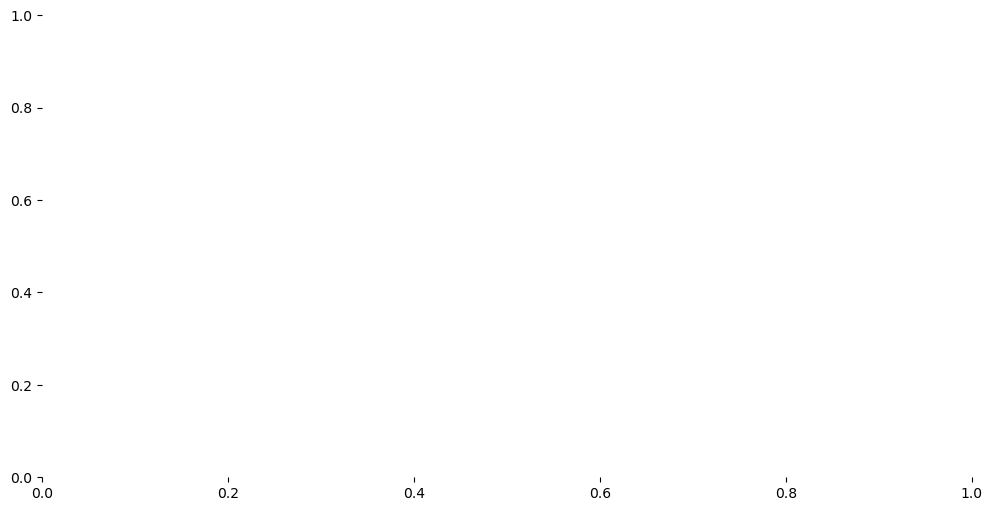

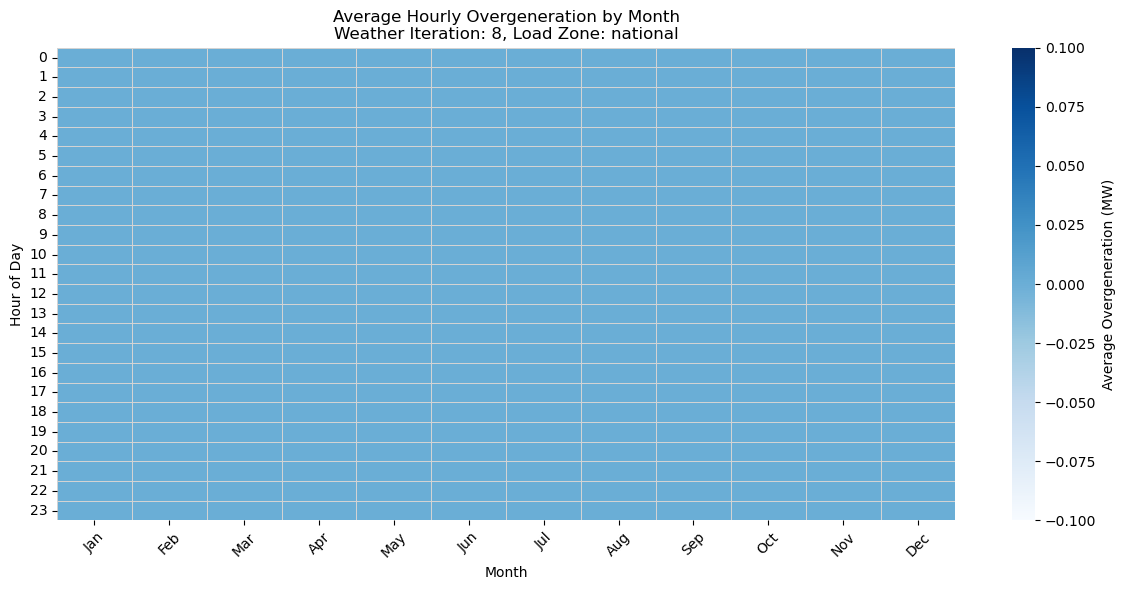

Could not generate Unserved Energy heatmap for iteration 8: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 9


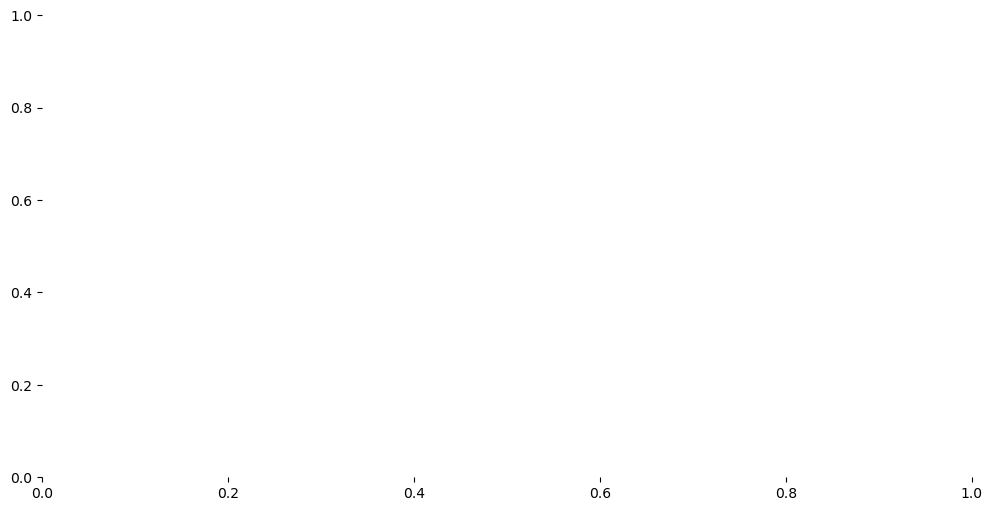

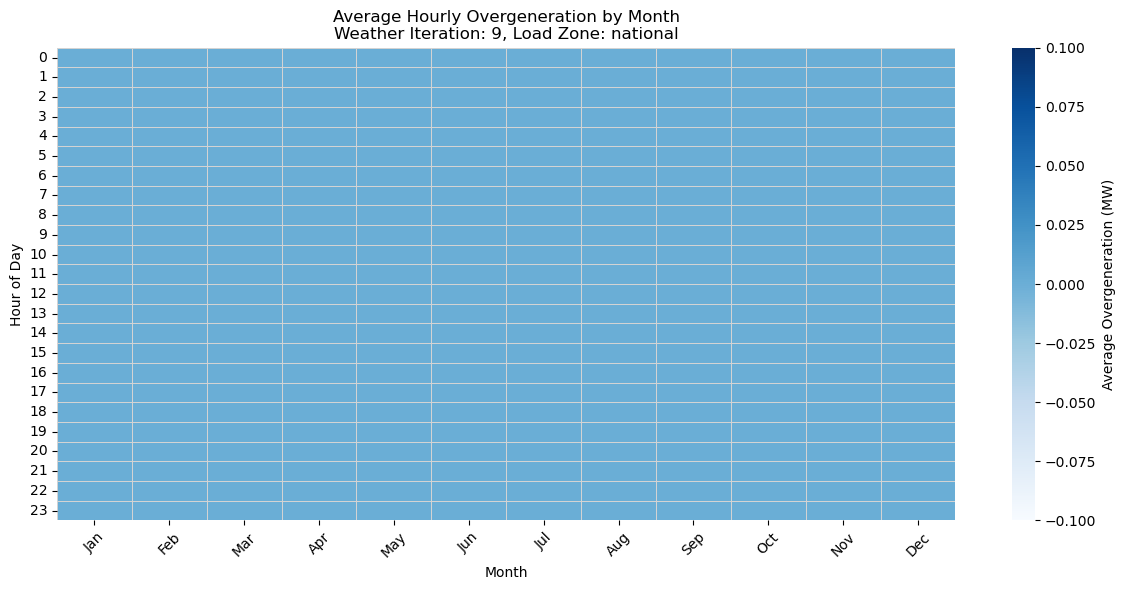

Could not generate Unserved Energy heatmap for iteration 9: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 10


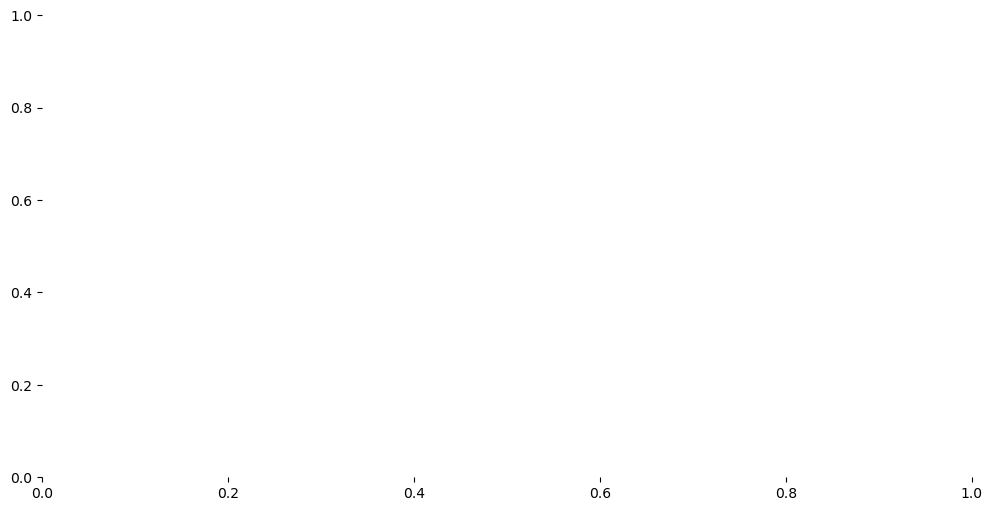

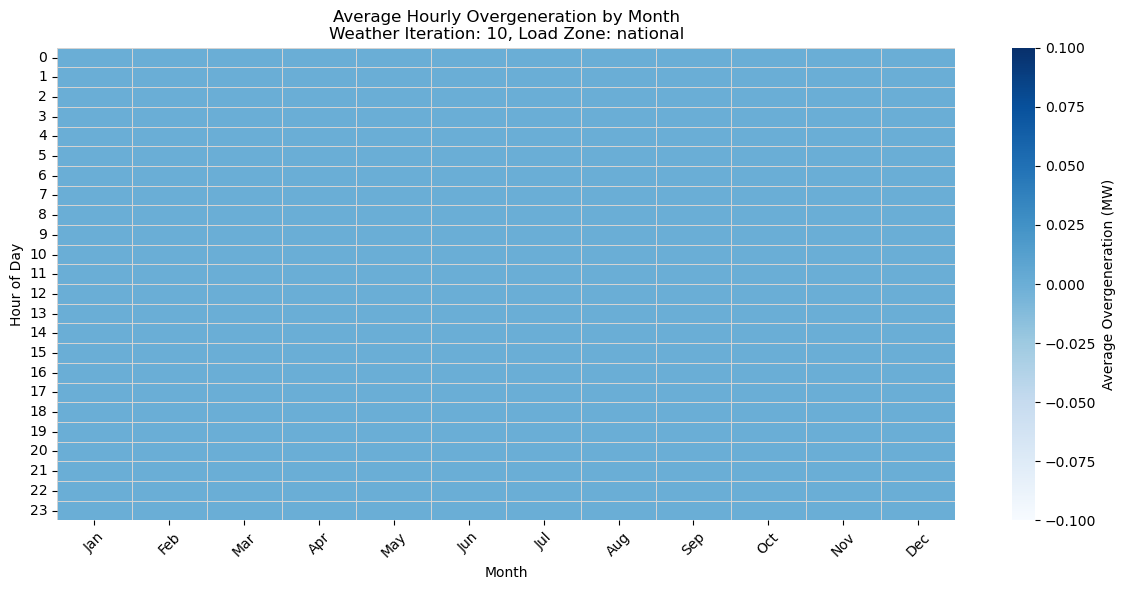

Could not generate Unserved Energy heatmap for iteration 10: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 12


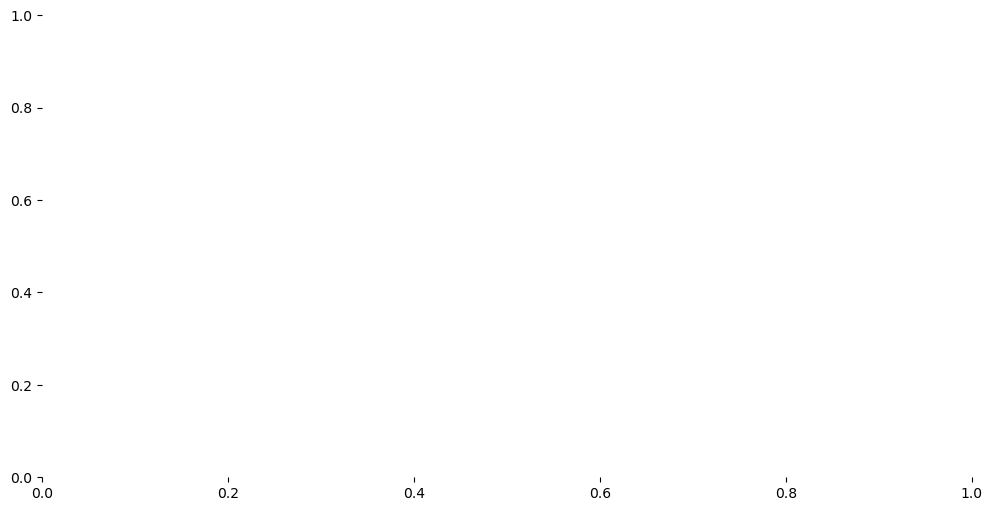

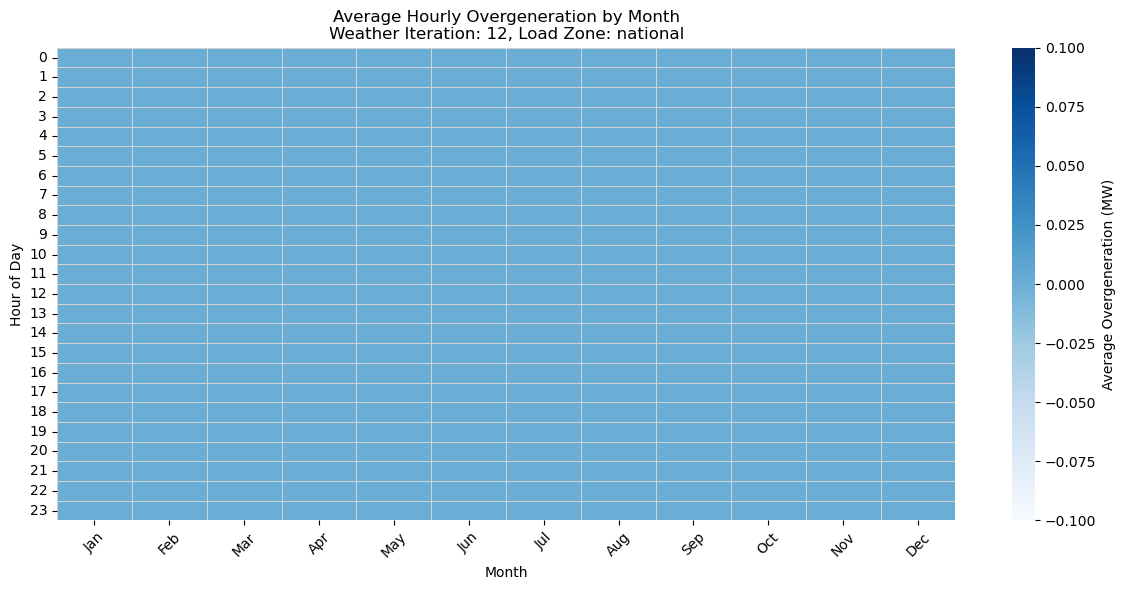

Could not generate Unserved Energy heatmap for iteration 12: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 16


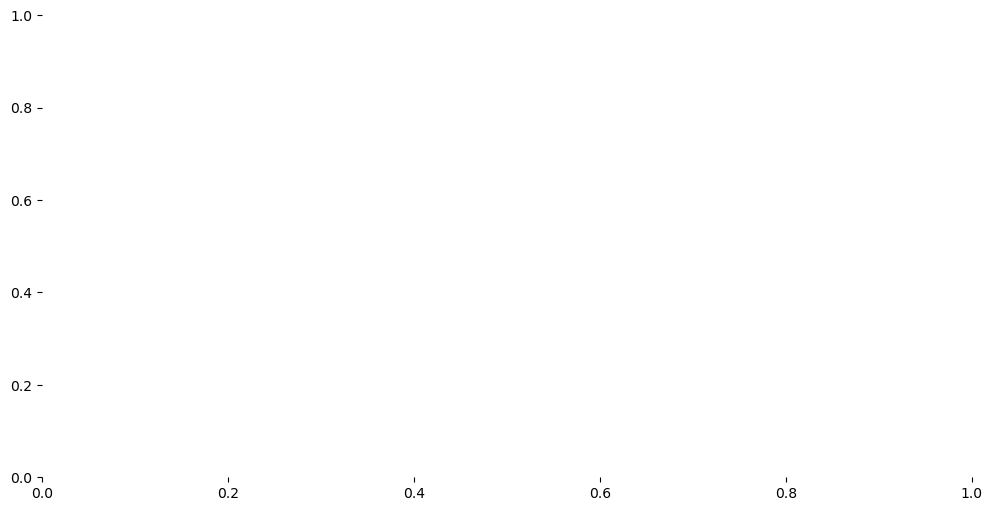

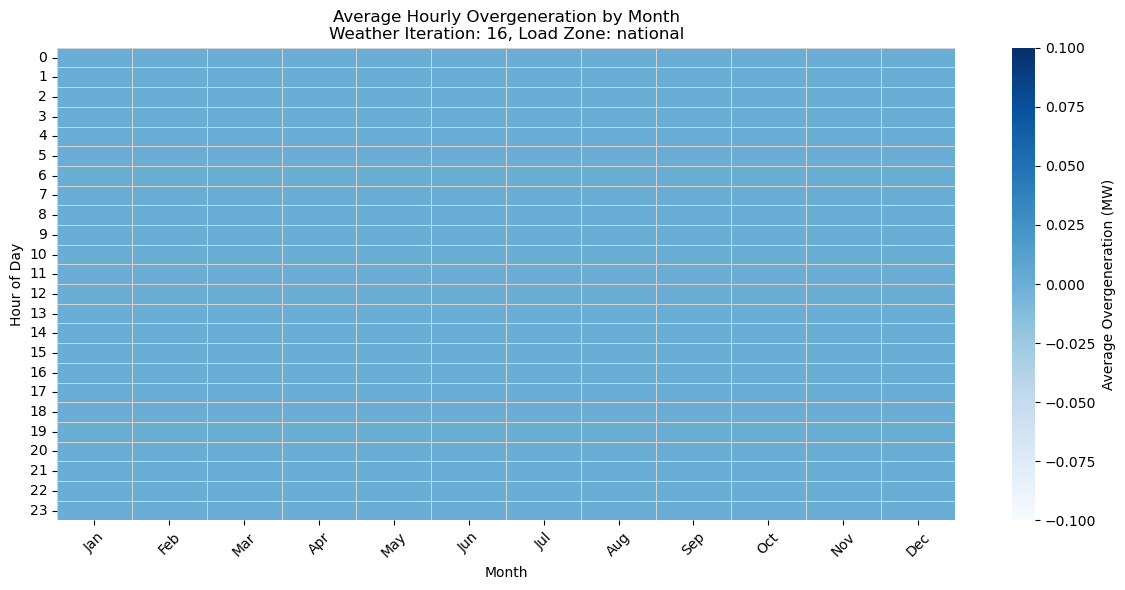

Could not generate Unserved Energy heatmap for iteration 16: QuadMesh.set() got an unexpected keyword argument 'na_color'

Processing Plots for Weather Iteration: 17


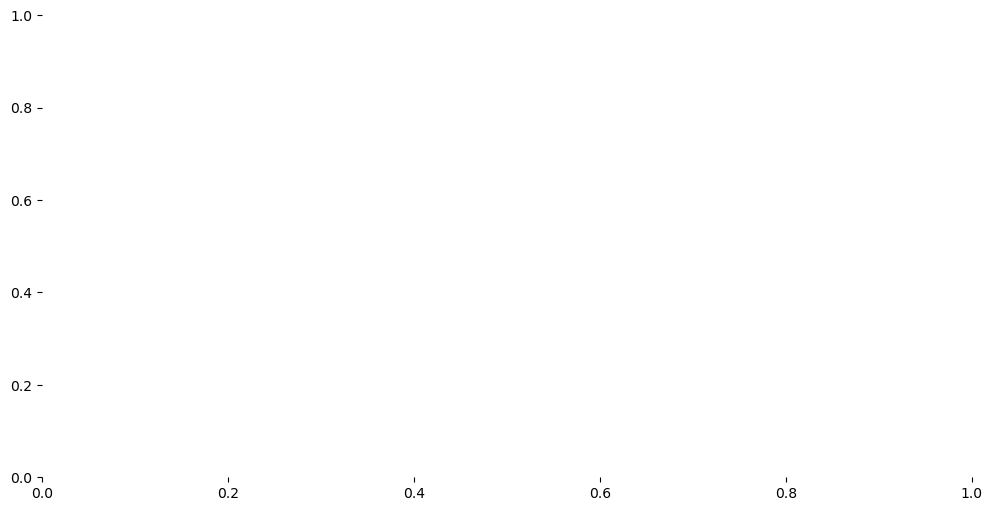

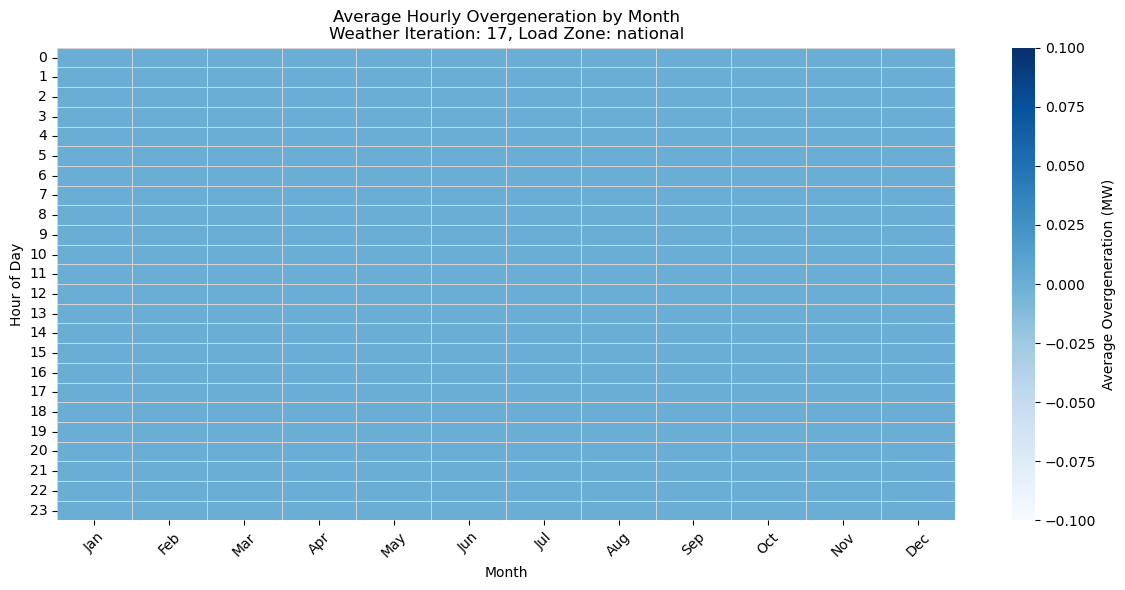

Could not generate Unserved Energy heatmap for iteration 17: QuadMesh.set() got an unexpected keyword argument 'na_color'


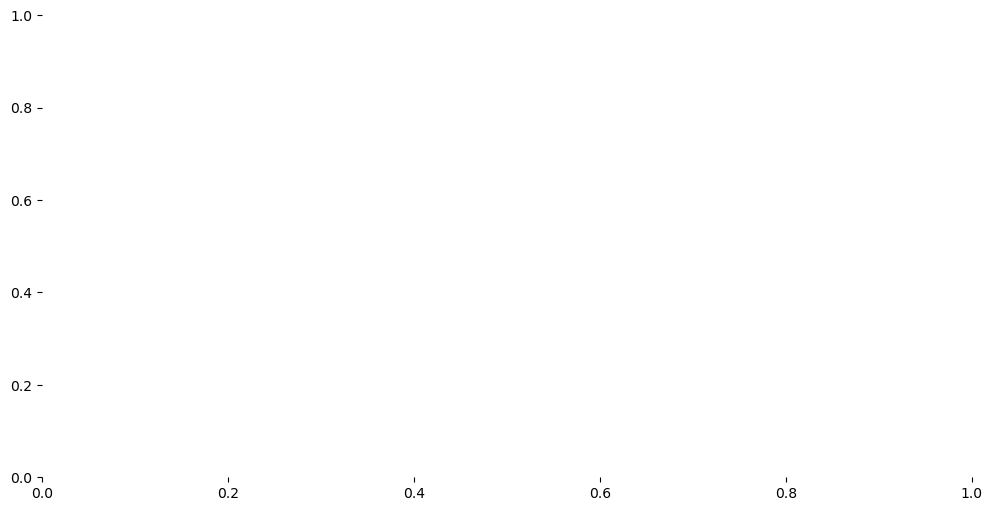

In [3]:
# --- Debug Check ---
if 'aggregated_system_load_df' in locals():
    print(f"Debug: Type of aggregated_system_load_df: {type(aggregated_system_load_df)}")
    print(f"Debug: Is aggregated_system_load_df empty? {aggregated_system_load_df.empty}")
    if not aggregated_system_load_df.empty:
        print(f"Debug: Shape of aggregated_system_load_df: {aggregated_system_load_df.shape}")
        print("Debug: First 5 rows of aggregated_system_load_df:")
        print(aggregated_system_load_df.head())
else:
    print("Debug: aggregated_system_load_df is not defined in locals.")
# --- End Debug Check ---

#plot heatmaps each for every weather_iteration. the X axis should be months and Y axis should be hours. the color should be the overgeneration_mw (blue) and unserved_energy_mw (red). 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np # Make sure numpy is imported

# Function to plot heatmaps for each weather iteration
def plot_heatmaps_by_iteration(df, selected_zone):
    # Check if the DataFrame exists and is not empty
    if not isinstance(df, pd.DataFrame) or df.empty:
        print("Input DataFrame for plotting not found or is empty. Cannot plot heatmaps.")
        return

    required_cols = ['timestamp', 'weather_iteration', 'overgeneration_mw', 'unserved_energy_mw']
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        print(f"Error: Missing required columns for plotting: {missing}")
        return

    # Make a copy to avoid SettingWithCopyWarning
    df_plot = df.copy()

    # Ensure timestamp is datetime and extract month/hour
    try:
        df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])
        df_plot['month'] = df_plot['timestamp'].dt.month
        df_plot['hour'] = df_plot['timestamp'].dt.hour
    except Exception as e:
        print(f"Error converting timestamp or extracting month/hour: {e}")
        return

    # Get unique weather iterations from the processed DataFrame (df_plot)
    weather_iterations = df_plot['weather_iteration'].unique()
    weather_iterations.sort()

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    for iteration in weather_iterations:
        print(f"\nProcessing Plots for Weather Iteration: {iteration}")
        # Filter the processed DataFrame (df_plot) for the current iteration
        iter_df = df_plot[df_plot['weather_iteration'] == iteration].copy()

        # --- Overgeneration Heatmap ---
        try:
            # Use iter_df which now contains 'hour' and 'month'
            pivot_overgen = iter_df.pivot_table(index='hour', columns='month', values='overgeneration_mw', aggfunc='mean')
            # Reindex columns to ensure correct month order
            pivot_overgen = pivot_overgen.reindex(columns=range(1, 13))
            pivot_overgen.columns = month_names

            plt.figure(figsize=(12, 6))
            sns.heatmap(pivot_overgen, cmap="Blues", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Average Overgeneration (MW)'})
            plt.title(f'Average Hourly Overgeneration by Month\nWeather Iteration: {iteration}, Load Zone: {selected_zone}')
            plt.xlabel('Month')
            plt.ylabel('Hour of Day')
            plt.yticks(rotation=0)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not generate Overgeneration heatmap for iteration {iteration}: {e}")

        # --- Unserved Energy Heatmap ---
        try:
            pivot_unserved = iter_df.pivot_table(index='hour', columns='month', values='unserved_energy_mw', aggfunc='mean')
            # Reindex columns to ensure correct month order
            pivot_unserved = pivot_unserved.reindex(columns=range(1, 13))
            pivot_unserved.columns = month_names

            # Use a threshold to avoid plotting tiny values if they aren't meaningful
            # Set values below a small threshold (e.g., 0.01 MW) to NaN so they don't dominate the color scale if most values are zero
            unserved_threshold = 0.01
            pivot_unserved[pivot_unserved < unserved_threshold] = np.nan

            if pivot_unserved.isnull().all().all():
                #  print(f"No significant unserved energy (> {unserved_threshold} MW) found for iteration {iteration}. Skipping heatmap.")
                 continue

            plt.figure(figsize=(12, 6))
            sns.heatmap(pivot_unserved, cmap="Reds", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Average Unserved Energy (MW)'}, na_color='white') # Show NaN as white
            plt.title(f'Average Hourly Unserved Energy by Month\nWeather Iteration: {iteration}, Load Zone: {selected_zone}')
            plt.xlabel('Month')
            plt.ylabel('Hour of Day')
            plt.yticks(rotation=0)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not generate Unserved Energy heatmap for iteration {iteration}: {e}")

# Check if aggregated_system_load_df exists before calling
if 'aggregated_system_load_df' in locals():
    plot_heatmaps_by_iteration(aggregated_system_load_df, selected_load_zone)
else:
    print("Variable 'aggregated_system_load_df' not defined. Cannot run plotting function.")

In [4]:
# make a table for using the unserved energy column to calculate the loss of load metrics like EUE (MW/loss-of-load-hour. Average capacity shortage in a loss of load hour ) 
# LOLE, LOLP (Probability of encountering lost load in a given year,day, and hour), and LOLH (hrs/yr. Expected number of hours with lost load in a year)
# Average Event Duration (hrs. 3 Average number of hours of lost load on a day with  lost load) 



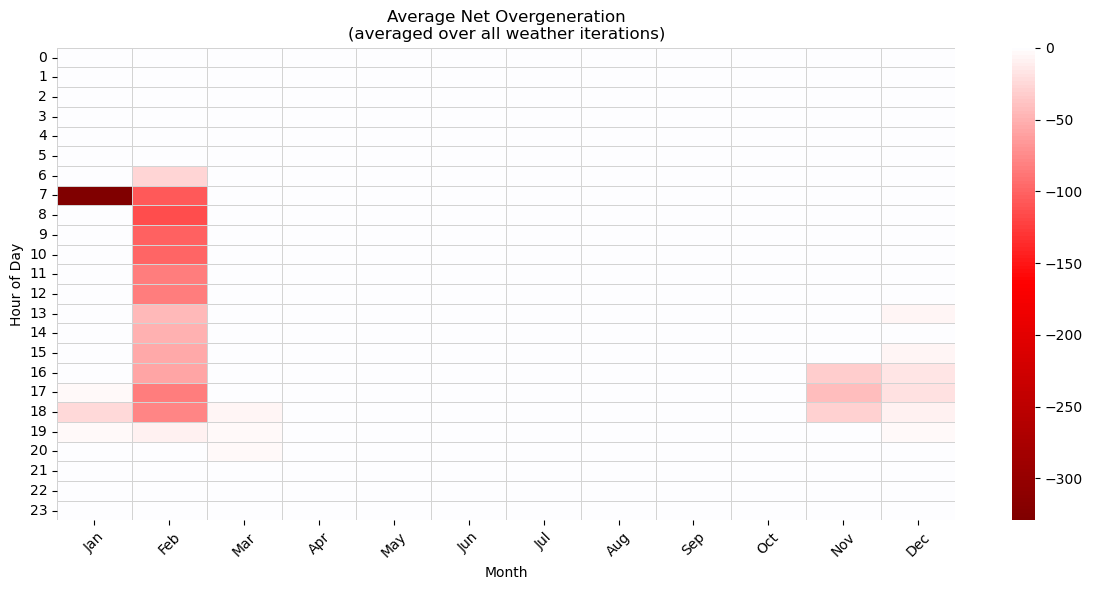

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prepare DataFrame (replace with your variable if different)
df = aggregated_system_load_df.copy()

# 2) Ensure timestamp, month & hour
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month'] = df['timestamp'].dt.month
df['hour']  = df['timestamp'].dt.hour

# 3) Pivot average over all weather iterations
pivot_overgen = df.pivot_table(
    index='hour', 
    columns='month', 
    values='overgeneration_mw', 
    aggfunc='mean'
).reindex(index=range(0,24), columns=range(1,13), fill_value=0)

pivot_unserved = df.pivot_table(
    index='hour', 
    columns='month', 
    values='unserved_energy_mw', 
    aggfunc='mean'
).reindex(index=range(0,24), columns=range(1,13), fill_value=0)

# 4) Compute net: positive = overgeneration exceeds unserved
pivot_net = pivot_overgen - pivot_unserved

# 5) Plot single diverging heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_net, 
    cmap='seismic_r',      # blue for positive (overgen), red for negative (unserved)
    center=0, 
    linewidths=0.5, 
    linecolor='lightgray',
    cbar_kws={'label': ''}
)
plt.title('Average Net Overgeneration\n(averaged over all weather iterations)')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.xticks(ticks=np.arange(12)+0.5, labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


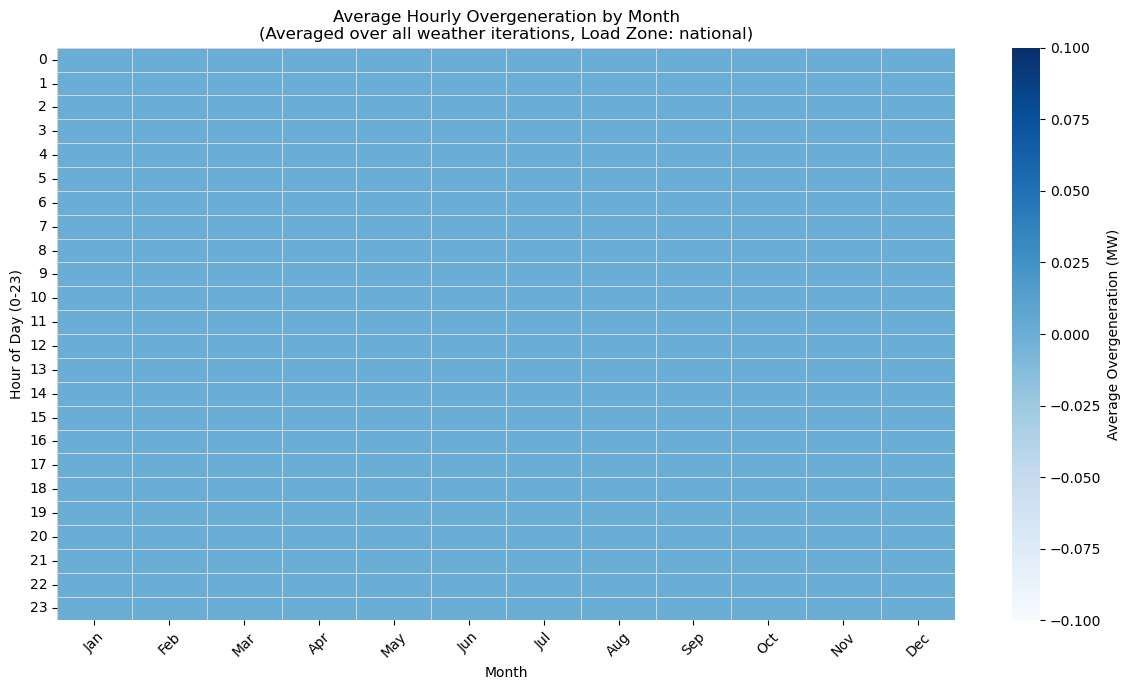

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Ensure aggregated_system_load_df exists and is not empty
if 'aggregated_system_load_df' in locals() and not aggregated_system_load_df.empty:
    df_plot = aggregated_system_load_df.copy()

    # Ensure timestamp is datetime and extract month & hour
    df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])
    df_plot['month'] = df_plot['timestamp'].dt.month
    df_plot['hour']  = df_plot['timestamp'].dt.hour

    # Create pivot table for overgeneration, averaging over all weather iterations
    pivot_overgen_avg = df_plot.pivot_table(
        index='hour', 
        columns='month', 
        values='overgeneration_mw', 
        aggfunc='mean'  # Average over all entries for each hour-month combination
    )

    # Reindex to ensure all months (1-12) and hours (0-23) are present, fill missing with 0
    pivot_overgen_avg = pivot_overgen_avg.reindex(index=range(0,24), columns=range(1,13), fill_value=0)

    # Define month labels for the x-axis
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # Plot the heatmap
    plt.figure(figsize=(12, 7))
    sns.heatmap(
        pivot_overgen_avg, 
        cmap="Blues",      # Use a blue color map for overgeneration
        linewidths=.5, 
        linecolor='lightgray',
        cbar_kws={'label': 'Average Overgeneration (MW)'},
        annot=False # Set to True if you want values on the heatmap cells
    )
    plt.title(f'Average Hourly Overgeneration by Month\n(Averaged over all weather iterations, Load Zone: {selected_load_zone})')
    plt.xlabel('Month')
    plt.ylabel('Hour of Day (0-23)')
    plt.xticks(ticks=np.arange(12) + 0.5, labels=month_labels, rotation=45)
    plt.yticks(ticks=np.arange(24) + 0.5, labels=np.arange(24), rotation=0) # Ensure all hour labels are shown
    plt.tight_layout()
    plt.show()
    
    # Optional: Print the pivot table data
    # print("\nPivot table for average overgeneration (MW):")
    # print(pivot_overgen_avg)

else:
    print("aggregated_system_load_df not found or is empty. Cannot generate the heatmap.")

In [7]:
import pandas as pd
import numpy as np

if 'aggregated_system_load_df' in locals() and not aggregated_system_load_df.empty:
    df_calc = aggregated_system_load_df.copy()

    # Ensure 'timestamp' is datetime and add 'date' column
    df_calc['timestamp'] = pd.to_datetime(df_calc['timestamp'])
    df_calc['date']      = df_calc['timestamp'].dt.date

    # Define a threshold for considering an hour as a "loss of load" hour
    loss_of_load_threshold = 0.0

    # Identify hours with loss of load across all data
    is_lol_hour_event = df_calc['unserved_energy_mw'] > loss_of_load_threshold

    # Number of unique simulation years
    num_sim_years = df_calc['weather_iteration'].nunique()
    if num_sim_years == 0:
        print("Warning: No unique weather_iterations found. Assuming 1 simulation year for averaging.")
        num_sim_years = 1

    # --- Totals across all runs ---
    total_lol_hours_all_runs           = is_lol_hour_event.sum()
    total_unserved_energy_mwh_all_runs = df_calc.loc[is_lol_hour_event, 'unserved_energy_mw'].sum()

    # --- Year‐average metrics ---
    lolh_hrs_per_avg_year       = total_lol_hours_all_runs / num_sim_years
    total_ue_mwh_per_avg_year   = total_unserved_energy_mwh_all_runs / num_sim_years
    eue_mw_per_lolh             = (total_unserved_energy_mwh_all_runs / total_lol_hours_all_runs) if total_lol_hours_all_runs > 0 else 0.0

    # --- LOLE (days/avg year) ---
    df_lol_events               = df_calc[is_lol_hour_event]
    total_lol_days_all_runs     = df_lol_events[['weather_iteration','date']].drop_duplicates().shape[0] if not df_lol_events.empty else 0
    lole_days_per_avg_year      = total_lol_days_all_runs / num_sim_years

    # --- LOLP probabilities & durations ---
    total_hours_all_runs            = len(df_calc)
    total_distinct_days_all_runs    = df_calc[['weather_iteration','date']].drop_duplicates().shape[0]
    hourly_lolp                     = total_lol_hours_all_runs / total_hours_all_runs if total_hours_all_runs > 0 else 0.0
    daily_lolp                      = total_lol_days_all_runs / total_distinct_days_all_runs if total_distinct_days_all_runs > 0 else 0.0
    avg_lol_event_duration_hrs_per_lol_day = (total_lol_hours_all_runs / total_lol_days_all_runs) if total_lol_days_all_runs > 0 else 0.0

    # --- NENS: Normalized Energy Not Served ---
    total_static_load_mwh_all_runs = df_calc['static_load_mw'].sum()
    nens = (total_unserved_energy_mwh_all_runs / total_static_load_mwh_all_runs) if total_static_load_mwh_all_runs > 0 else 0.0

    # --- Assemble results ---
    results_list = [{
        'Time Span': 'All Weather Years Combined',
        'Number of Simulation Years': num_sim_years,
        'LOLH (hrs/avg. yr)'                      : lolh_hrs_per_avg_year,
        'Total Unserved Energy (MWh/avg. yr)'     : total_ue_mwh_per_avg_year,
        'EUE (MW/LOLH)'                           : eue_mw_per_lolh,
        'LOLE (days/avg. yr)'                     : lole_days_per_avg_year,
        'Hourly LOLP (overall)'                   : hourly_lolp,
        'Daily LOLP (overall)'                    : daily_lolp,
        'Avg. LOL Event Duration (hrs/LOL day)'   : avg_lol_event_duration_hrs_per_lol_day,
        'NENS (normalized energy not served)'     : nens,
        'Total LOL Hours (all years)'             : total_lol_hours_all_runs,
        'Total LOL Days (all years)'              : total_lol_days_all_runs,
        'Total Unserved Energy (MWh, all years)'  : total_unserved_energy_mwh_all_runs
    }]

    reliability_metrics_df = pd.DataFrame(results_list)

    print("\nAggregated Reliability Metrics (Considering All Weather Years):")
    # Transpose to make single-row metrics more readable
    print(reliability_metrics_df.T.to_string(header=False))

else:
    print("aggregated_system_load_df not found or is empty. Cannot calculate reliability metrics.")
    reliability_metrics_df = pd.DataFrame()



Aggregated Reliability Metrics (Considering All Weather Years):
Time Span                               All Weather Years Combined
Number of Simulation Years                                      13
LOLH (hrs/avg. yr)                                       23.692308
Total Unserved Energy (MWh/avg. yr)                   44602.156929
EUE (MW/LOLH)                                          1882.558572
LOLE (days/avg. yr)                                      17.846154
Hourly LOLP (overall)                                     0.002705
Daily LOLP (overall)                                      0.048894
Avg. LOL Event Duration (hrs/LOL day)                     1.327586
NENS (normalized energy not served)                       0.000011
Total LOL Hours (all years)                                    308
Total LOL Days (all years)                                     232
Total Unserved Energy (MWh, all years)               579828.040083


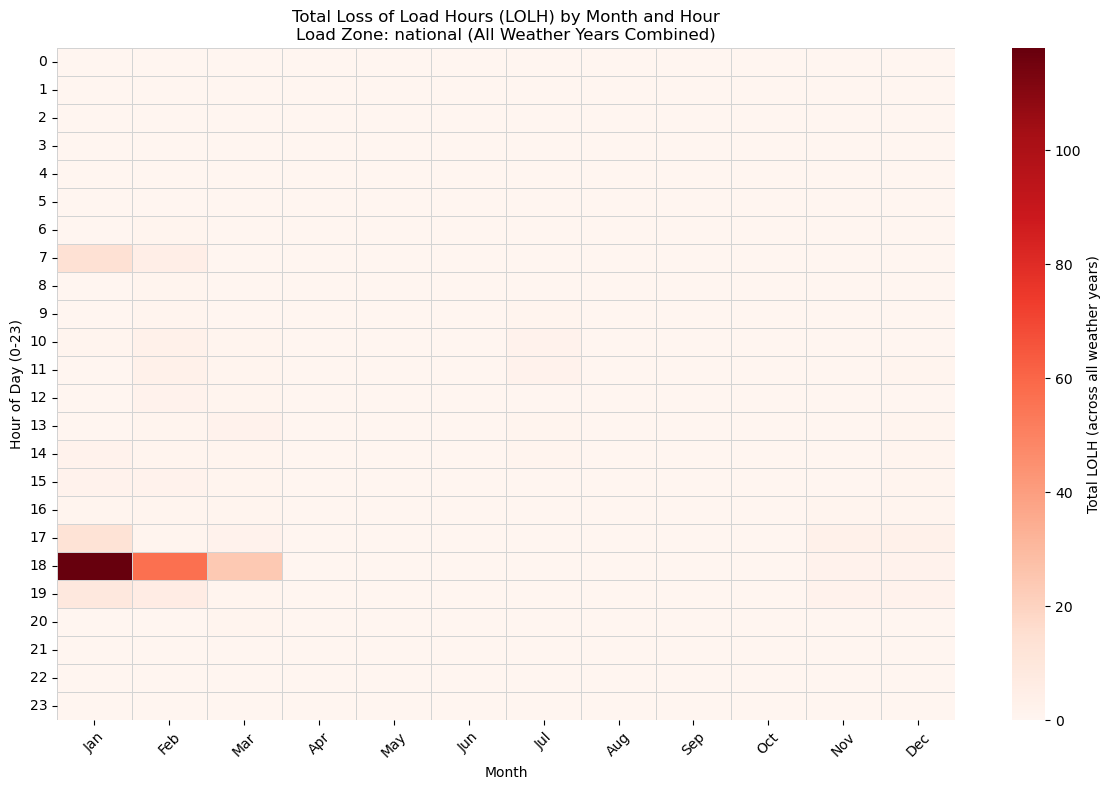


Loss of Load Hours (LOLH) > 0 by Month and Hour (All Weather Years Combined):
Could not generate LOLH heatmap: 'month'
LOLH pivot data head:
   month  hour  lolh_sum
0      1     0         0
1      1     1         0
2      1     2         0
3      1     3         0
4      1     4         0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported
import numpy as np # Ensure numpy is imported

if 'aggregated_system_load_df' in locals() and not aggregated_system_load_df.empty:
    df_plot_lolh = aggregated_system_load_df.copy()

    # Ensure 'timestamp' is datetime
    df_plot_lolh['timestamp'] = pd.to_datetime(df_plot_lolh['timestamp'])
    df_plot_lolh['month'] = df_plot_lolh['timestamp'].dt.month
    df_plot_lolh['hour'] = df_plot_lolh['timestamp'].dt.hour

    # Define a threshold for considering an hour as a "loss of load" hour
    # This should be consistent with the threshold used in reliability calculations
    loss_of_load_threshold = 0.0 
    df_plot_lolh['is_lol_hour'] = df_plot_lolh['unserved_energy_mw'] > loss_of_load_threshold

    # Calculate LOLH: Sum of LOL hours for each month-hour combination across all weather years
    # Group by month and hour, and sum the 'is_lol_hour' boolean (True=1, False=0)
    # This effectively counts the number of times a loss of load occurred for that specific month-hour slot
    # across all simulated years.
    lolh_pivot_data = df_plot_lolh.groupby(['month', 'hour'])['is_lol_hour'].sum().reset_index()
    # Rename 'is_lol_hour' to 'lolh_sum' for clarity as it now represents the sum of LOL hours
    lolh_pivot_data.rename(columns={'is_lol_hour': 'lolh_sum'}, inplace=True)
    
    # Pivot the table for heatmap
    try:
        pivot_lolh = lolh_pivot_data.pivot_table(index='hour', columns='month', values='lolh_sum', fill_value=0)
        
        # Reindex columns to ensure correct month order (1-12) and fill missing months with 0
        pivot_lolh = pivot_lolh.reindex(columns=range(1, 13), fill_value=0)
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        pivot_lolh.columns = month_names
        
        # Reindex rows to ensure all hours 0-23 are present, fill missing hours with 0
        pivot_lolh = pivot_lolh.reindex(index=range(0, 24), fill_value=0)

        # Check if there's any LOLH to plot
        if pivot_lolh.sum().sum() == 0:
            print("No Loss of Load Hours (LOLH > 0) recorded across all weather years. Heatmap will be blank or not generated.")
            # Optionally, still show a blank heatmap or skip plotting
            # plt.figure(figsize=(12, 6))
            # sns.heatmap(pivot_lolh, cmap="Reds", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Total LOLH (across all weather years)'}, annot=False)
            # plt.title(f'Total Loss of Load Hours (LOLH) by Month and Hour\nLoad Zone: {selected_load_zone} (All Weather Years)')
            # plt.xlabel('Month')
            # plt.ylabel('Hour of Day')
            # plt.yticks(rotation=0)
            # plt.xticks(rotation=45)
            # plt.tight_layout()
            # plt.show()
        else:
            plt.figure(figsize=(12, 8)) # Increased height for better y-axis label visibility
            sns.heatmap(pivot_lolh, cmap="Reds", linewidths=.5, linecolor='lightgray', 
                        cbar_kws={'label': 'Total LOLH (across all weather years)'}, 
                        annot=False) # annot=True can be used if numbers are desired on cells
            plt.title(f'Total Loss of Load Hours (LOLH) by Month and Hour\nLoad Zone: {selected_load_zone} (All Weather Years Combined)')
            plt.xlabel('Month')
            plt.ylabel('Hour of Day (0-23)')
            plt.yticks(ticks=np.arange(0.5, 24.5, 1), labels=np.arange(0, 24, 1), rotation=0) # Ensure all hour labels are shown
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        # Display LOLH values > 0
        significant_lolh = lolh_pivot_data[lolh_pivot_data['lolh_sum'] > 0]
        if not significant_lolh.empty:
            print("\nLoss of Load Hours (LOLH) > 0 by Month and Hour (All Weather Years Combined):")
            # Map month numbers to names for better readability
            significant_lolh_display = significant_lolh.copy() # Avoid SettingWithCopyWarning
            significant_lolh_display['month_name'] = significant_lolh_display['month'].apply(lambda x: month_names[x-1])
            print(significant_lolh_display[['month_name', 'hour', 'lolh_sum']].sort_values(by=['month', 'hour']).to_string(index=False))
        else:
            print("\nNo Loss of Load Hours (LOLH > 0) recorded to display.")

    except Exception as e:
        print(f"Could not generate LOLH heatmap: {e}")
        if 'lolh_pivot_data' in locals():
            print("LOLH pivot data head:")
            print(lolh_pivot_data.head())

else:
    print("aggregated_system_load_df not found or is empty. Cannot generate LOLH heatmap.")


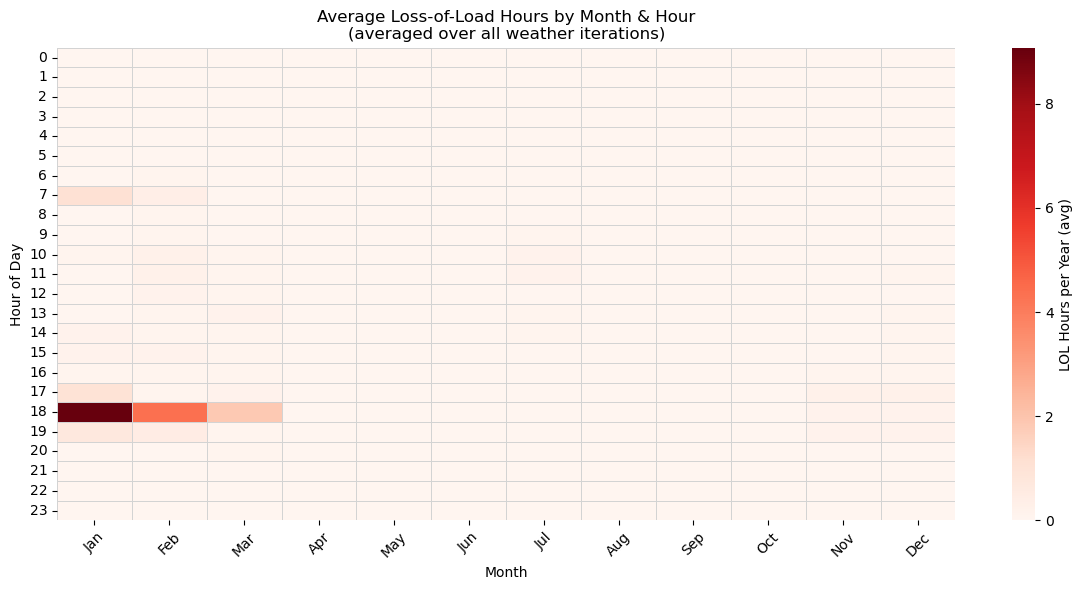

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) Prepare DataFrame ---
if 'aggregated_system_load_df' not in locals() or aggregated_system_load_df.empty:
    raise ValueError("aggregated_system_load_df is not defined or is empty")

df = aggregated_system_load_df.copy()

# Ensure timestamp is datetime, extract month & hour
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month']     = df['timestamp'].dt.month
df['hour']      = df['timestamp'].dt.hour

# --- 2) Flag each hour as a LOL event ---
loss_of_load_threshold = 0.0
df['lol_event'] = (df['unserved_energy_mw'] > loss_of_load_threshold).astype(int)

# --- 3) Count LOLH by (hour, month) ---
lolh_counts = (
    df
    .pivot_table(
        index='hour',
        columns='month',
        values='lol_event',
        aggfunc='sum'
    )
    .reindex(index=range(0,24), columns=range(1,13), fill_value=0)
)

# --- 4) Normalize to average per simulation year ---
num_years = df['weather_iteration'].nunique() or 1
lolh_avg = lolh_counts / num_years

# --- 5) Plot heatmap ---
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(12, 6))
sns.heatmap(
    lolh_avg,
    cmap='Reds',
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={'label': 'LOL Hours per Year (avg)'}
)
plt.title('Average Loss-of-Load Hours by Month & Hour\n(averaged over all weather iterations)')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.xticks(np.arange(12)+0.5, month_labels, rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


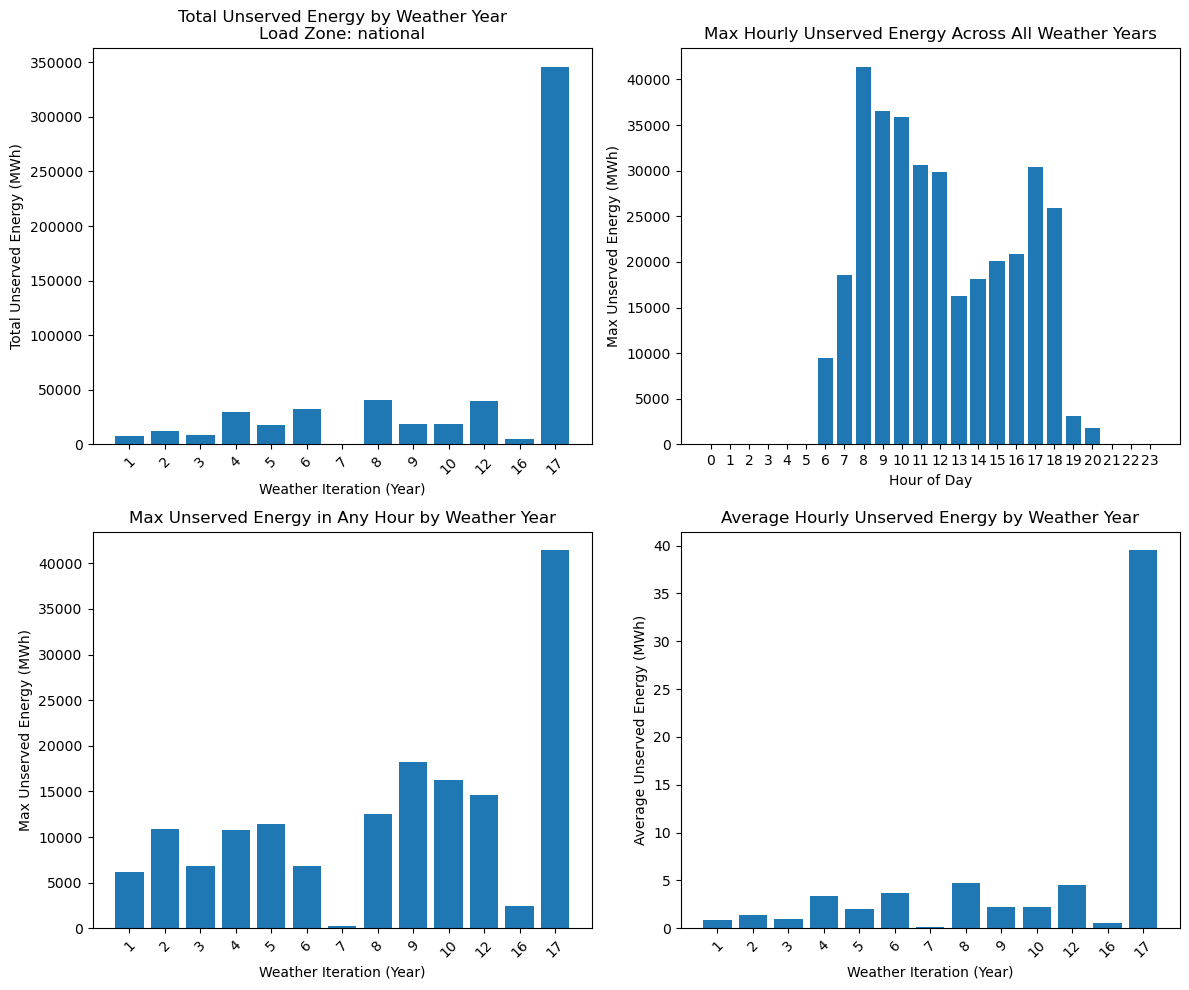

Total Unserved Energy (MWh) by Weather Year:
weather_iteration
1       7981.343388
2      11899.111298
3       8640.954848
4      29550.081658
5      18046.397326
6      32548.141546
7        873.040480
8      41181.723602
9      19143.156630
10     19124.773900
12     39901.045920
16      4920.254952
17    346018.014534

Max Hourly Unserved Energy (MWh) Across All Weather Years:
hour
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6      9493.710599
7     18627.511581
8     41409.117139
9     36594.006020
10    35846.079801
11    30582.687594
12    29878.050560
13    16289.792188
14    18127.344967
15    20065.167322
16    20869.981788
17    30438.353304
18    25910.211255
19     3151.526958
20     1751.236913
21        0.000000
22        0.000000
23        0.000000

Max Unserved Energy (MWh) in a Single Hour by Weather Year:
weather_iteration
1      6140.063174
2     10844.840181
3      6792.189858
4     10765.888213
5

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare dataframe and calculated metrics
df = aggregated_system_load_df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

yearly_sum = df.groupby('weather_iteration')['unserved_energy_mw'].sum()
max_by_hour = df.groupby('hour')['unserved_energy_mw'].max()
yearly_max = df.groupby('weather_iteration')['unserved_energy_mw'].max()
yearly_avg = df.groupby('weather_iteration')['unserved_energy_mw'].mean()

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Total unserved energy by year
axes[0, 0].bar(yearly_sum.index.astype(str), yearly_sum)
axes[0, 0].set_title(f'Total Unserved Energy by Weather Year\nLoad Zone: {selected_load_zone}')
axes[0, 0].set_xlabel('Weather Iteration (Year)')
axes[0, 0].set_ylabel('Total Unserved Energy (MWh)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Max hourly unserved energy by hour
axes[0, 1].bar(max_by_hour.index, max_by_hour)
axes[0, 1].set_title('Max Hourly Unserved Energy Across All Weather Years')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Max Unserved Energy (MWh)')
axes[0, 1].set_xticks(range(0, 24))

# Max unserved energy in any hour by year
axes[1, 0].bar(yearly_max.index.astype(str), yearly_max)
axes[1, 0].set_title('Max Unserved Energy in Any Hour by Weather Year')
axes[1, 0].set_xlabel('Weather Iteration (Year)')
axes[1, 0].set_ylabel('Max Unserved Energy (MWh)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Average hourly unserved energy by year
axes[1, 1].bar(yearly_avg.index.astype(str), yearly_avg)
axes[1, 1].set_title('Average Hourly Unserved Energy by Weather Year')
axes[1, 1].set_xlabel('Weather Iteration (Year)')
axes[1, 1].set_ylabel('Average Unserved Energy (MWh)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print the data series for reference
print("Total Unserved Energy (MWh) by Weather Year:")
print(yearly_sum.to_string())
print("\nMax Hourly Unserved Energy (MWh) Across All Weather Years:")
print(max_by_hour.to_string())
print("\nMax Unserved Energy (MWh) in a Single Hour by Weather Year:")
print(yearly_max.to_string())
print("\nAverage Hourly Unserved Energy (MWh) by Weather Year:")
print(yearly_avg.to_string())


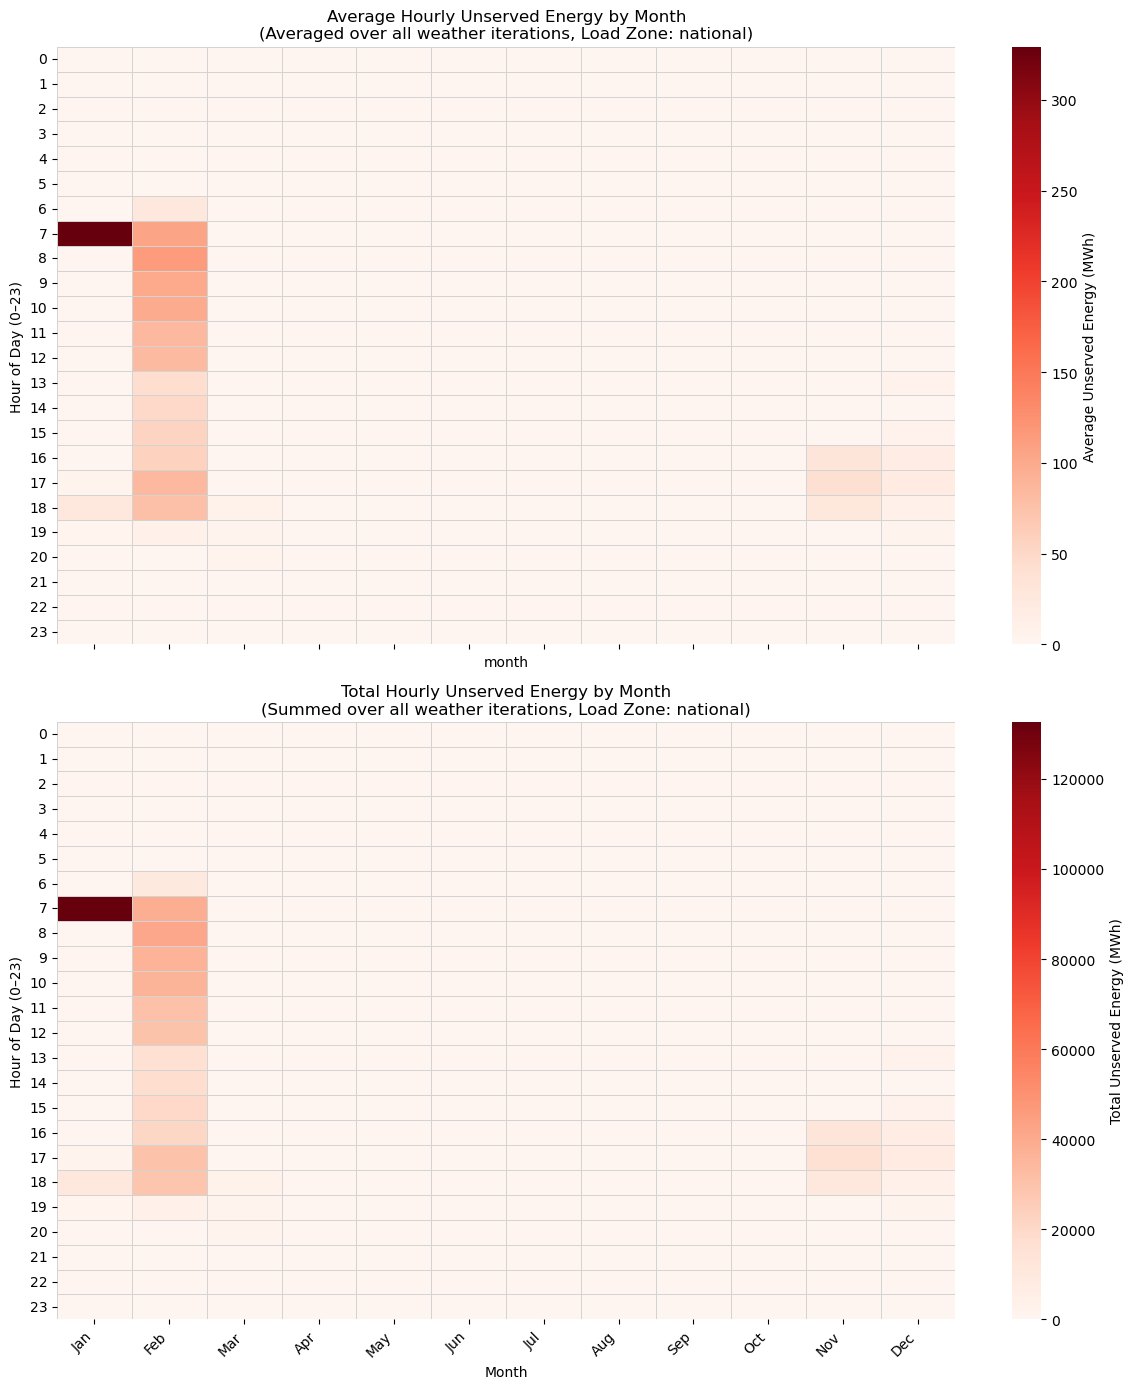

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Only proceed if the DataFrame exists and is non‐empty
if 'aggregated_system_load_df' in locals() and not aggregated_system_load_df.empty:
    # Prepare the data once
    df = aggregated_system_load_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['month']     = df['timestamp'].dt.month
    df['hour']      = df['timestamp'].dt.hour

    # Pivot for average unserved energy
    pivot_avg = (
        df
        .pivot_table(index='hour', columns='month', values='unserved_energy_mw', aggfunc='mean')
        .reindex(index=range(24), columns=range(1,13), fill_value=0)
    )

    # Pivot for total unserved energy
    pivot_total = (
        df
        .pivot_table(index='hour', columns='month', values='unserved_energy_mw', aggfunc='sum')
        .reindex(index=range(24), columns=range(1,13), fill_value=0)
    )

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    # Create the figure and two axes (2 rows, 1 column)
    fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

    # Top: Average unserved energy
    sns.heatmap(
        pivot_avg,
        ax=axes[0],
        cmap="Reds",
        linewidths=0.5,
        linecolor='lightgray',
        cbar_kws={'label': 'Average Unserved Energy (MWh)'},
        annot=False
    )
    axes[0].set_title(f'Average Hourly Unserved Energy by Month\n(Averaged over all weather iterations, Load Zone: {selected_load_zone})')
    axes[0].set_ylabel('Hour of Day (0–23)')
    axes[0].set_yticks(np.arange(24) + 0.5)
    axes[0].set_yticklabels(np.arange(24), rotation=0)

    # Bottom: Total unserved energy
    sns.heatmap(
        pivot_total,
        ax=axes[1],
        cmap="Reds",
        linewidths=0.5,
        linecolor='lightgray',
        cbar_kws={'label': 'Total Unserved Energy (MWh)'},
        annot=False
    )
    axes[1].set_title(f'Total Hourly Unserved Energy by Month\n(Summed over all weather iterations, Load Zone: {selected_load_zone})')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Hour of Day (0–23)')
    axes[1].set_xticks(np.arange(12) + 0.5)
    axes[1].set_xticklabels(month_labels, rotation=45, ha='right')
    axes[1].set_yticks(np.arange(24) + 0.5)
    axes[1].set_yticklabels(np.arange(24), rotation=0)

    plt.tight_layout()
    plt.show()

else:
    print("aggregated_system_load_df not found or is empty. Cannot generate the heatmaps.")


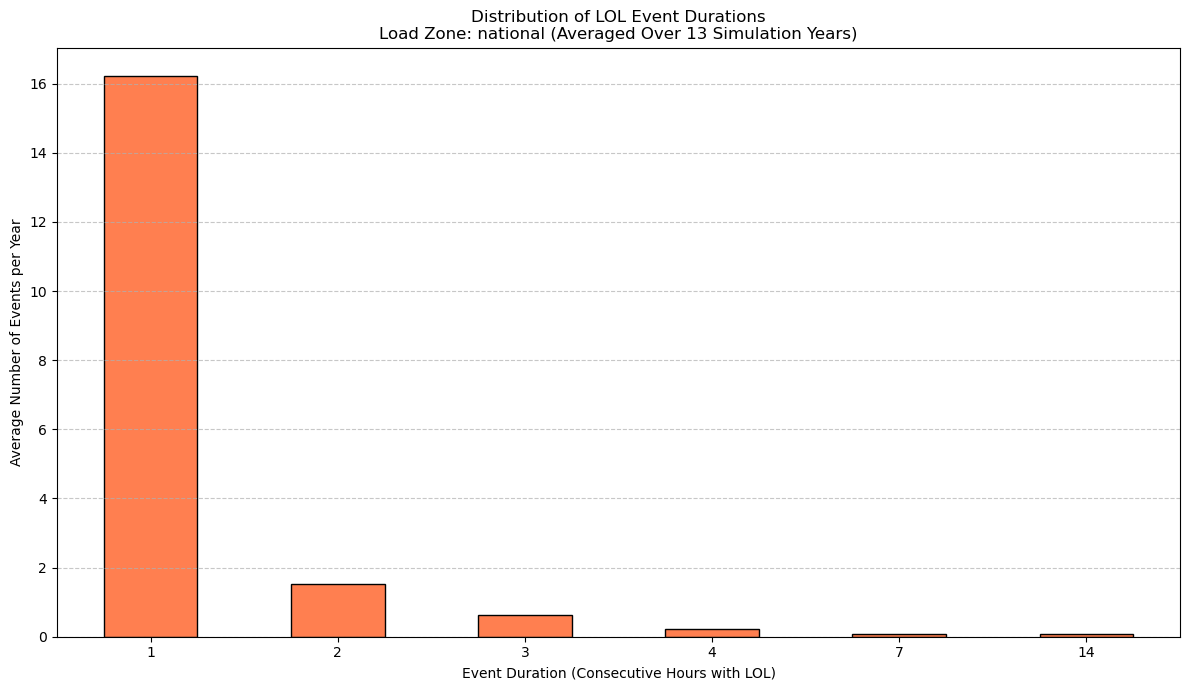


Average Number of LOL Events per Year by Duration (Load Zone: national):
1     16.230769
2      1.538462
3      0.615385
4      0.230769
7      0.076923
14     0.076923


In [12]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

if 'aggregated_system_load_df' in locals() and not aggregated_system_load_df.empty:
    df_plot_events = aggregated_system_load_df.copy()

    # Define loss of load threshold (consistent with previous cells)
    loss_of_load_threshold = 0.0
    df_plot_events['is_lol_hour'] = df_plot_events['unserved_energy_mw'] > loss_of_load_threshold

    # Calculate num_sim_years from the dataframe
    num_sim_years = df_plot_events['weather_iteration'].nunique()
    if num_sim_years == 0:
        print("Warning: No unique weather_iterations found. Assuming 1 simulation year for averaging.")
        num_sim_years = 1

    all_event_durations = []

    if 'is_lol_hour' in df_plot_events.columns:
        # Ensure data is sorted by weather_iteration and then by timestamp for correct event grouping
        df_plot_events = df_plot_events.sort_values(['weather_iteration', 'timestamp'])

        for iteration, group_df in df_plot_events.groupby('weather_iteration'):
            # Identify groups of consecutive LOL hours within this iteration
            # A 'lol_event_block_id' is a unique ID for each continuous block of LOL or non-LOL hours
            # It increments each time 'is_lol_hour' changes from its previous value
            group_df['lol_event_block_id'] = (group_df['is_lol_hour'] != group_df['is_lol_hour'].shift()).cumsum()
            
            # Filter for actual LOL hours
            lol_hours_in_iteration = group_df[group_df['is_lol_hour']]
            
            if not lol_hours_in_iteration.empty:
                # For each LOL event (identified by 'lol_event_block_id'), count the number of hours (its duration)
                durations_this_iteration = lol_hours_in_iteration.groupby('lol_event_block_id').size()
                all_event_durations.extend(durations_this_iteration.tolist())
    
    if not all_event_durations:
        print(f"No loss of load events (unserved_energy_mw > {loss_of_load_threshold}) found for load zone: {selected_load_zone}.")
        print("Cannot generate event duration distribution chart.")
    else:
        # Convert list of durations to a Pandas Series for easy counting
        event_durations_series = pd.Series(all_event_durations)
        
        # Count the occurrences of each unique duration
        duration_counts = event_durations_series.value_counts().sort_index()
        
        # Calculate average number of events per year for each duration
        avg_events_per_year_for_duration = duration_counts / num_sim_years
        
        # Plotting
        plt.figure(figsize=(12, 7))
        avg_events_per_year_for_duration.plot(kind='bar', color='coral', edgecolor='black')
        plt.title(f'Distribution of LOL Event Durations\nLoad Zone: {selected_load_zone} (Averaged Over {num_sim_years} Simulation Years)')
        plt.xlabel('Event Duration (Consecutive Hours with LOL)')
        plt.ylabel('Average Number of Events per Year')
        
        # Improve x-axis readability if many unique durations
        if len(avg_events_per_year_for_duration.index) > 15:
             plt.xticks(rotation=90, ha='right')
        else:
             plt.xticks(rotation=0)

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"\nAverage Number of LOL Events per Year by Duration (Load Zone: {selected_load_zone}):")
        print(avg_events_per_year_for_duration.to_string())

else:
    print("aggregated_system_load_df not found or is empty. Cannot generate LOL event duration chart.")

 event duration distribution, which will have on Y axis events per year (an event is unserved energy in a timepoint) and on x axis event duration (in hrs)